# Projeto Machine Learning II – Classificação de Sons Urbanos

## 1. Contexto
O som urbano faz parte essencial do ambiente em que vivemos. A classificação automática de sons urbanos (como buzinas, sirenes ou crianças a brincar) é relevante para aplicações em **segurança**, **monitorização ambiental**, **cidades inteligentes** e **recuperação de multimédia**. Apesar da extensa pesquisa em áudio, poucos trabalhos lidam com **sons urbanos reais**, e a ausência de datasets padronizados dificulta a comparação de resultados.

## 2. Objetivo do Projeto
O objetivo deste projeto é desenvolver **classificadores de deep learning** capazes de identificar a qual das 10 classes pertence um trecho de áudio urbano. Para isso, serão implementados dois modelos de redes neurais à escolha entre **MLP, CNN e RNN**, permitindo avaliar e comparar o desempenho de cada um.

## 3. Dataset UrbanSound8K

### 3.1. Dataset metadata

- **slice_file_name**: O nome do ficheiro de áudio.
- **fsID**: O ID do Freesound da gravação de onde este excerto (slice) foi retirado.
- **start**: O momento inicial do excerto na gravação original do Freesound.
- **end**: O momento final do excerto na gravação original do Freesound.
- **salience**: Uma classificação (subjetiva) da importância do som.  
  - **1** = som em primeiro plano  
  - **2** = som de fundo
- **fold**: O número do *fold* (1–10) ao qual este ficheiro foi atribuído (usado em divisões de treino/teste).
- **classID**: Um identificador numérico da classe do som.
- **class**: O nome da classe do som (a etiqueta que descreve o tipo de som).


### 3.2 Propriedades do áudio digital

As principais características que descrevem áudio digital — e que queremos analisar neste notebook — são:

- **Canais**: número de canais de áudio (mono/estéreo).
- **Taxa de Amostragem (Sample Rate)**: número de amostras por segundo, expresso em quilohertz (kHz); está relacionado com a qualidade do áudio.
- **Profundidade de Bits (Bit Depth)**: equivalente à resolução em imagens; descreve o nível de detalhe.
- **Duração**: comprimento do som ao longo do tempo.

As várias propriedades do áudio apresentam formatos e estruturas distintos. O primeiro passo é perceber como cada uma delas se distribui no conjunto de dados e analisar de que forma podemos padronizá-las, por exemplo, convertendo-as.






In [1]:
#bibliotecas 

import librosa 
import glob
import numpy as np
import soundata
import soundfile as sf
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import KFold
import pandas as pd
import os, json
from tqdm import tqdm
import random
import soundfile as sf
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import f_classif
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, classification_report
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, mixed_precision
import tensorflow as tf
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import foolbox as fb
import librosa.display
import joblib
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
import seaborn as sns 


### 1. Exploratory Data Analysis – EDA

Nesta etapa, o objetivo é compreender melhor a estrutura e as características do conjunto de dados UrbanSound8K, verificando o tipo de informações disponíveis, se há valores ausentes, e como as classes estão distribuídas.
Isso é essencial para preparar o dataset antes de qualquer modelagem.

In [2]:
dataset = soundata.initialize('urbansound8k')
#dataset.download(force_overwrite=True)
#dataset.validate()
print(os.listdir(os.path.join(dataset.data_home)))
print(os.listdir(os.path.join(dataset.data_home, "audio")))
dataset_path = os.path.join(dataset.data_home, "audio") 
print("Dataset path:", dataset.data_home)

# Caminho para o CSV
metadata_path = os.path.join(dataset.data_home, "metadata", "UrbanSound8K.csv")
print("CSV path:", metadata_path)

# Ler o CSV
metadata = pd.read_csv(metadata_path)
metadata.head()

['audio', 'FREESOUNDCREDITS.txt', 'metadata', 'UrbanSound8K.tar.gz', 'UrbanSound8K_README.txt']
['.DS_Store', 'fold1', 'fold10', 'fold2', 'fold3', 'fold4', 'fold5', 'fold6', 'fold7', 'fold8', 'fold9']
Dataset path: /tmp\sound_datasets\urbansound8k
CSV path: /tmp\sound_datasets\urbansound8k\metadata\UrbanSound8K.csv


,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


#### 1.1- Estatísticas Descritivas 
Fornece informações como médias, valores mínimos e máximos e quartis das colunas numéricas — útil para verificar a consistência dos dados, por exemplo, se start < end

In [3]:
metadata.describe()

,fsID,start,end,salience,fold,classID
count,8732.000000,8732.000000,8732.000000,8732.000000,8732.000000,8732.000000
mean,116033.493816,38.645409,42.253312,1.347000,5.385937,4.592877
std,57991.017218,74.292126,74.369669,0.476043,2.846820,2.894544
min,344.000000,0.000000,0.105962,1.000000,1.000000,0.000000
25%,69942.250000,3.000000,6.839398,1.000000,3.000000,2.000000
50%,118279.000000,10.376492,14.000000,1.000000,5.000000,4.000000
75%,166942.000000,35.131372,38.866979,2.000000,8.000000,7.000000
max,209992.000000,600.125356,604.125356,2.000000,10.000000,9.000000


In [4]:
metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8732 entries, 0 to 8731
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   slice_file_name  8732 non-null   object 
 1   fsID             8732 non-null   int64  
 2   start            8732 non-null   float64
 3   end              8732 non-null   float64
 4   salience         8732 non-null   int64  
 5   fold             8732 non-null   int64  
 6   classID          8732 non-null   int64  
 7   class            8732 non-null   object 
dtypes: float64(2), int64(4), object(2)
memory usage: 545.9+ KB


O dataset não contém valores nulos, o que facilita a preparação

In [16]:
metadata.isnull().sum()

slice_file_name    0
fsID               0
start              0
end                0
salience           0
fold               0
classID            0
class              0
dtype: int64

## 1.1 Análise da Distribuição das Classes

Está bem distribuido em 8 classes , mas conseguimos perceber que "car_horn" e "gun_shot" têm valores significativamente diferentes que os restantes. Pode ser um problema futuro

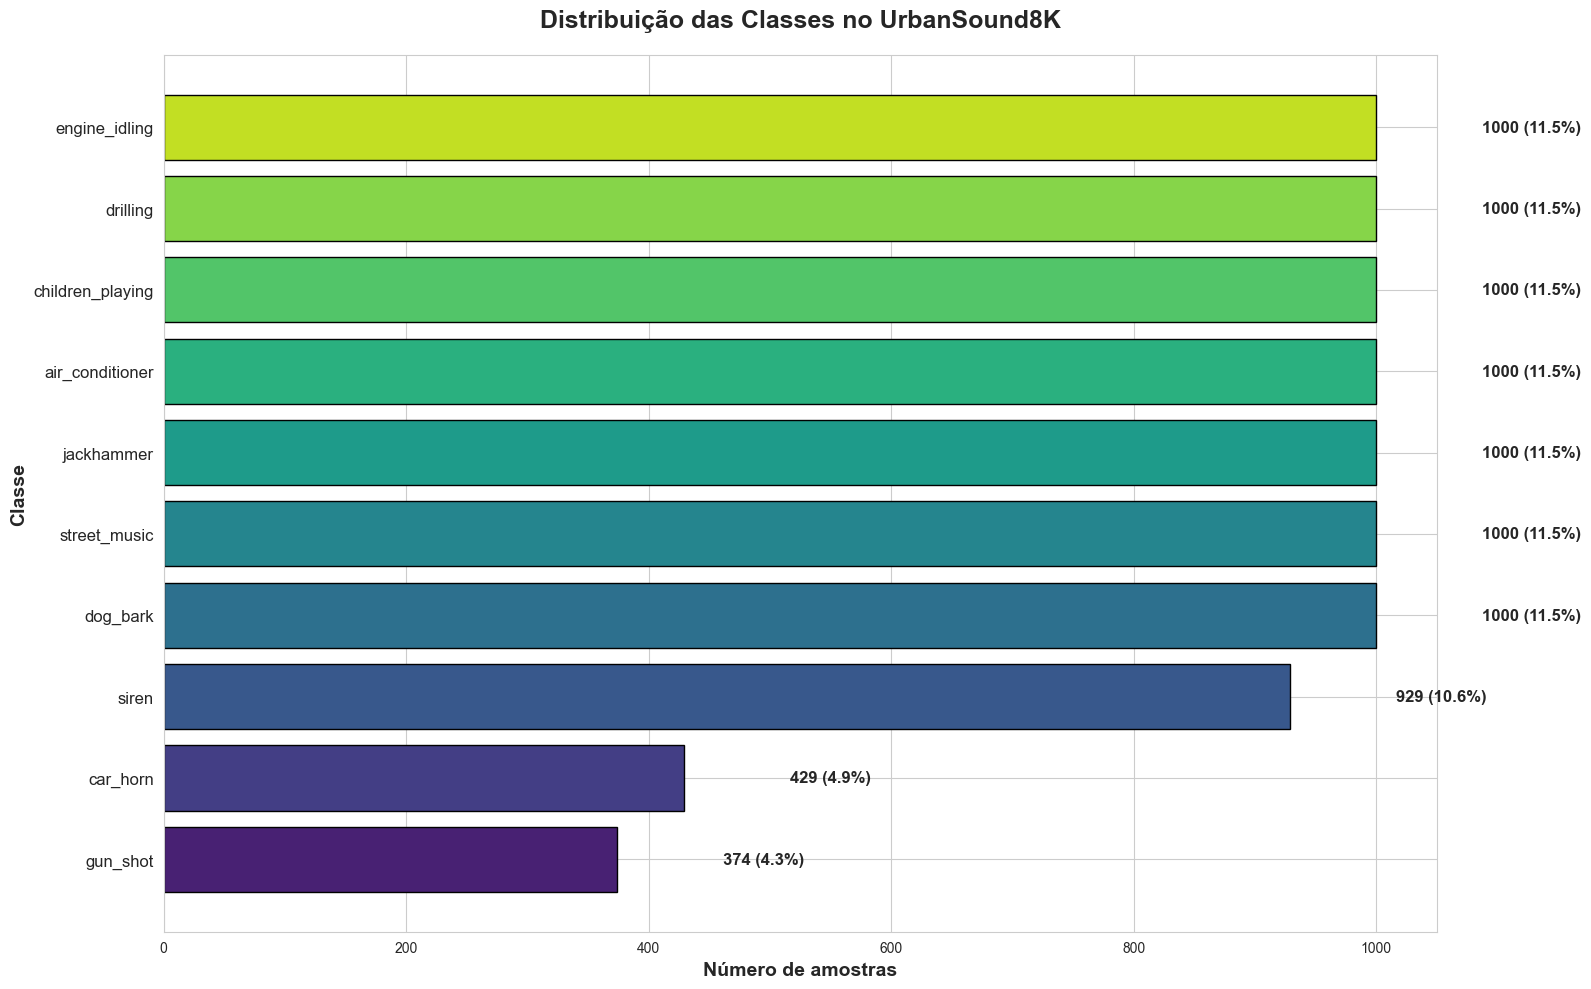

In [5]:
class_distribution = metadata['class'].value_counts().sort_values(ascending=True)
total_samples = class_distribution.sum()

plt.figure(figsize=(16, 10))  # figura maior para acomodar os nomes
sns.set_style("whitegrid")

# Paleta de cores graduais
colors = sns.color_palette("viridis", len(class_distribution))

# Criar gráfico de barras horizontais
bars = plt.barh(class_distribution.index, class_distribution.values, color=colors, edgecolor='black')

# Adicionar números e percentuais ao lado de cada barra
for bar, value in zip(bars, class_distribution.values):
    pct = value / total_samples * 100
    plt.text(value + total_samples*0.01, bar.get_y() + bar.get_height()/2, f"{value} ({pct:.1f}%)", 
             va='center', fontweight='bold', fontsize=12)

# Eixos e título
plt.xlabel("Número de amostras", fontsize=14, fontweight='bold')
plt.ylabel("Classe", fontsize=14, fontweight='bold')
plt.title("Distribuição das Classes no UrbanSound8K", fontsize=18, fontweight='bold', pad=20)

# Melhorar legibilidade dos nomes das classes
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


## 1.2 Propriedades do áudio

### 1.2.1 Comprimento do áudio

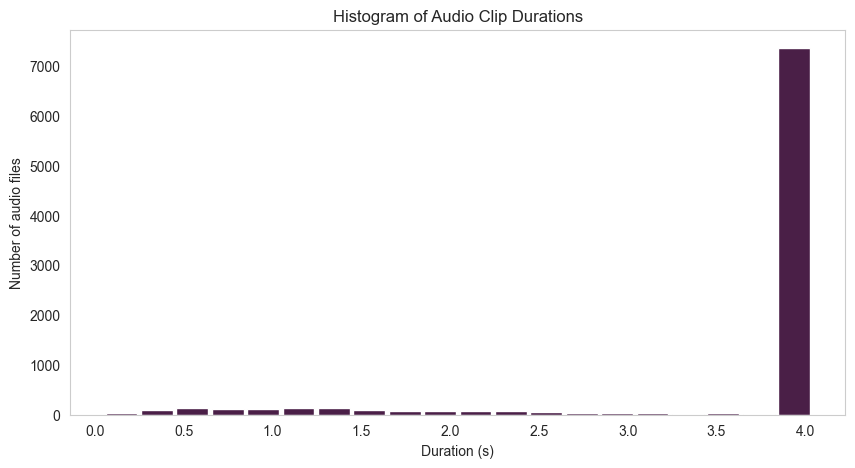

count    8732.000000
mean        3.607522
std         0.974394
min         0.050000
25%         4.000000
50%         4.000000
75%         4.000000
max         4.036647
Name: duration, dtype: float64


In [6]:
audio_durations = []

for idx, row in metadata.iterrows():
    fold = f'fold{row["fold"]}'
    file_name = str(row["slice_file_name"])
    file_path = os.path.join(dataset_path, fold, file_name)
    
    # Obtém info do ficheiro sem carregar o áudio
    info = sf.info(file_path)
    duration = info.frames / info.samplerate
    
    audio_durations.append((file_name, fold, row["class"], duration))

# Converte para DataFrame
durations_df = pd.DataFrame(audio_durations, columns=['file', 'fold', 'class', 'duration'])

# Histograma das durações
plt.figure(figsize=(10,5))
plt.hist(durations_df['duration'], bins=20, rwidth=0.9, color="#4a1f47")
plt.xlabel('Duration (s)')
plt.ylabel('Number of audio files')
plt.title('Histogram of Audio Clip Durations')
plt.grid(False)
plt.show()

# Estatísticas básicas
print(durations_df['duration'].describe())

### 1.2.2 Distribuição da frequência

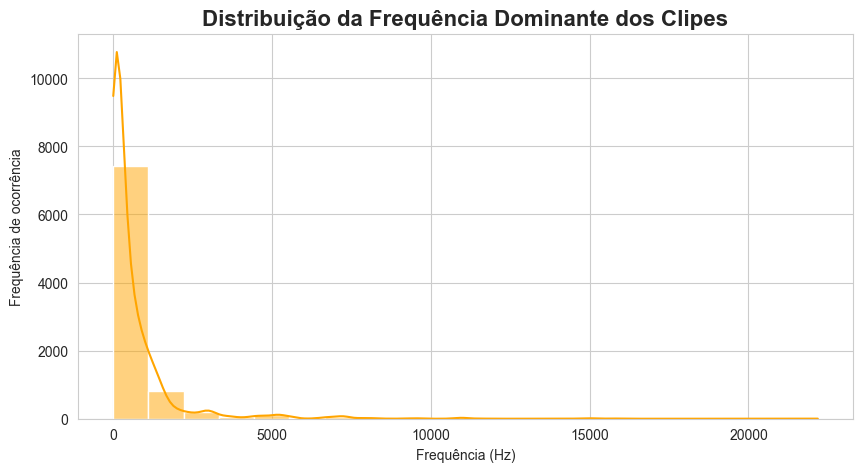

In [7]:
dominant_freqs = []

for index, row in metadata.iterrows():
    file_path = os.path.join(dataset_path, f"fold{row['fold']}", row['slice_file_name'])
    waveform, sr = librosa.load(file_path, sr=None)
    
    # FFT do sinal
    fft = np.fft.fft(waveform)
    fft_magnitude = np.abs(fft)
    fft_freqs = np.fft.fftfreq(len(fft), 1/sr)
    
    # Frequência dominante (excluindo negativas)
    pos_mask = fft_freqs > 0
    dominant_freq = fft_freqs[pos_mask][np.argmax(fft_magnitude[pos_mask])]
    dominant_freqs.append(dominant_freq)

plt.figure(figsize=(10, 5))
sns.histplot(dominant_freqs, bins=20, kde=True, color='orange')
plt.title("Distribuição da Frequência Dominante dos Clipes", fontsize=16, fontweight='bold')
plt.xlabel("Frequência (Hz)")
plt.ylabel("Frequência de ocorrência")
plt.show()

Aqui decidimos ver a frequência mais promenorizadamente 

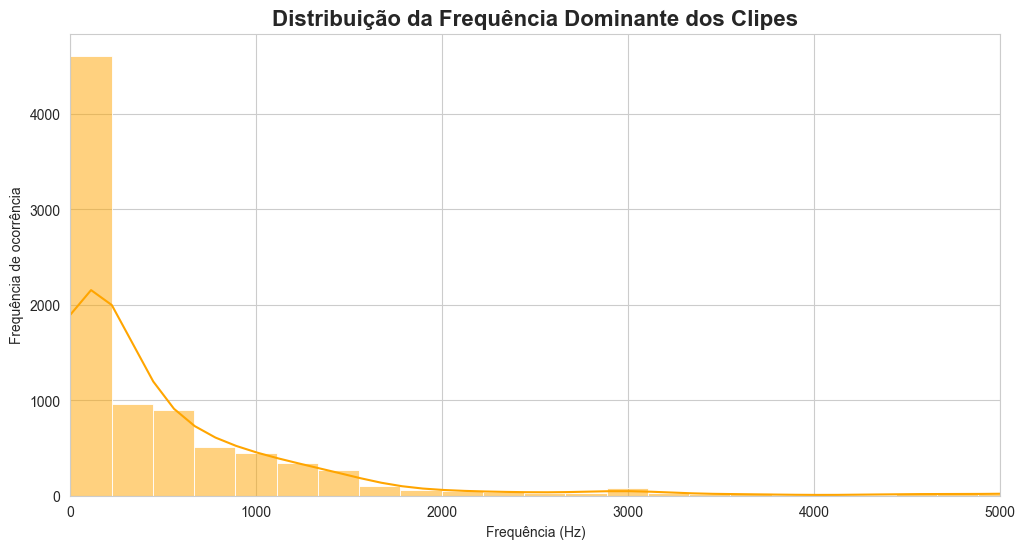

In [20]:
dominant_freqs = []

for index, row in metadata.iterrows():
    file_path = os.path.join(dataset_path, f"fold{row['fold']}", row['slice_file_name'])
    waveform, sr = librosa.load(file_path, sr=None)
    
    # FFT do sinal
    fft = np.fft.fft(waveform)
    fft_magnitude = np.abs(fft)
    fft_freqs = np.fft.fftfreq(len(fft), 1/sr)
    
    # Frequência dominante (excluindo negativas)
    pos_mask = fft_freqs > 0
    dominant_freq = fft_freqs[pos_mask][np.argmax(fft_magnitude[pos_mask])]
    dominant_freqs.append(dominant_freq)

plt.figure(figsize=(12, 6))
sns.histplot(dominant_freqs, bins=100, kde=True, color='orange')  # bins aumentados para mais detalhes
plt.title("Distribuição da Frequência Dominante dos Clipes", fontsize=16, fontweight='bold')
plt.xlabel("Frequência (Hz)")
plt.ylabel("Frequência de ocorrência")
plt.xlim(0, 5000)  # Limita o eixo x para melhor visualizar os detalhes mais importantes
plt.show()


### 1.2.3 Profundidade de bits

100%|██████████| 8732/8732 [00:00<00:00, 9086.15it/s]
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Contagem de bit depths:
bit_depth
16.0    5758
24.0    2753
32.0     169
Name: count, dtype: int64

Proporção de bit depths:
bit_depth
16.0    0.663364
24.0    0.317166
32.0    0.019470
Name: proportion, dtype: float64


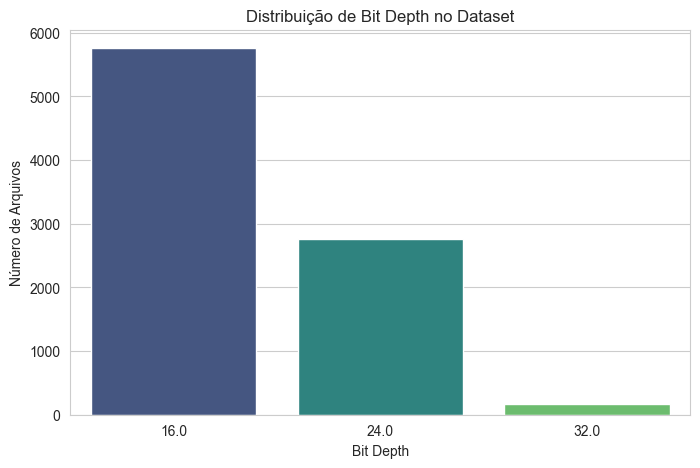

In [8]:
def check_audio_bit_depth(metadata, dataset_path):
    """
    Verifica o bit depth de todos os arquivos do dataset.
    Retorna um DataFrame com nome do arquivo, fold e bit depth.
    """
    data = []
    
    for idx, row in tqdm(metadata.iterrows(), total=len(metadata)):
        file_path = os.path.join(dataset_path, f"fold{row['fold']}", row['slice_file_name'])
        
        # Lê informações do arquivo
        info = sf.info(file_path)
        subtype = info.subtype  # ex: 'PCM_16', 'PCM_24', 'U8', 'FLOAT', 'PCM_4'
        
        # Tenta extrair número do bit depth diretamente de qualquer string
        import re
        match = re.search(r'\d+', subtype)
        bit_depth = int(match.group()) if match else None
        
        data.append((row['slice_file_name'], row['fold'], bit_depth))
    
    df = pd.DataFrame(data, columns=['file', 'fold', 'bit_depth'])
    return df

def check_audio_bit_depth(metadata, dataset_path):
    """
    Verifica o bit depth de todos os arquivos do dataset.
    Retorna um DataFrame com nome do arquivo, fold e bit depth.
    """
    data = []

    def subtype_to_bits(subtype):
        subtype = subtype.upper()
        if subtype.startswith("PCM_"):
            try:
                return int(subtype.split("_")[1])
            except:
                return None
        elif subtype == "U8":
            return 8
        elif subtype == "FLOAT":
            return 32
        elif subtype in ["ALAW", "ULAW"]:
            return 8
        else:
            return None

    for idx, row in tqdm(metadata.iterrows(), total=len(metadata)):
        file_path = os.path.join(dataset_path, f"fold{row['fold']}", row['slice_file_name'])
        info = sf.info(file_path)
        bit_depth = subtype_to_bits(info.subtype)
        data.append((row['slice_file_name'], row['fold'], bit_depth))

    df = pd.DataFrame(data, columns=['file', 'fold', 'bit_depth'])
    return df

# Executando a função
bit_depth_info = check_audio_bit_depth(metadata, dataset_path)

# Estatísticas
print("Contagem de bit depths:")
print(bit_depth_info['bit_depth'].value_counts())
print("\nProporção de bit depths:")
print(bit_depth_info['bit_depth'].value_counts(normalize=True))

# Plot da distribuição
plt.figure(figsize=(8,5))
sns.countplot(x='bit_depth', data=bit_depth_info, palette='viridis')
plt.xlabel("Bit Depth")
plt.ylabel("Número de Arquivos")
plt.title("Distribuição de Bit Depth no Dataset")
plt.show()


### 1.2.4 Análise do Número de Canais nos Arquivos de Áudio

Cada arquivo de áudio pode ter **um ou mais canais** de som:  

- **Mono**: apenas um canal de áudio. Todos os sons são misturados em um único canal.  
- **Estéreo**: dois canais de áudio separados, normalmente representando o som para os ouvidos esquerdo e direito.  

No dataset **UrbanSound8K**, a informação sobre o número de canais **não está presente no arquivo CSV de metadata**. Portanto, precisamos inspecionar os próprios arquivos de áudio para descobrir se são mono ou estéreo.  

Para isso, podemos utilizar a biblioteca `librosa` carregando os arquivos com `mono=False`, preservando os canais originais. A forma do array retornado indica o tipo de canal:

- Se `waveform.shape` for `(n_amostras,)` → **mono**  
- Se `waveform.shape` for `(2, n_amostras)` → **estéreo**  

Com isso, podemos gerar uma **nova coluna no DataFrame** indicando o tipo de cada arquivo de áudio, o que nos permite analisar a distribuição de arquivos mono e estéreo no dataset.  

> Observação: arquivos estéreo podem ser convertidos para mono por meio de uma média entre os dois canais, técnica comum em processamento de áudio, para simplificar a entrada em modelos de aprendizado de máquina.


100%|██████████| 8732/8732 [00:00<00:00, 9339.87it/s]
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Contagem de canais:
channels
2    7993
1     739
Name: count, dtype: int64

Proporção de canais:
channels
2    0.915369
1    0.084631
Name: proportion, dtype: float64


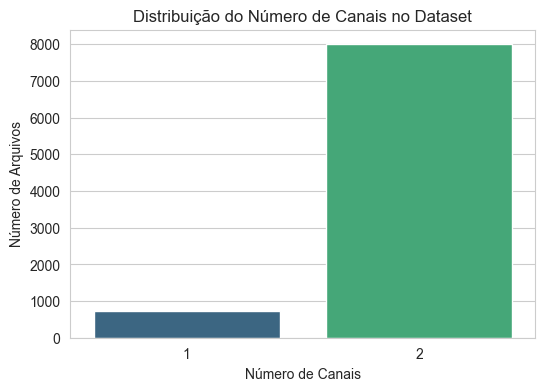

In [9]:
def check_audio_channels(metadata, dataset_path):
    """
    Verifica o número de canais de todos os arquivos do dataset.
    Retorna um DataFrame com nome do arquivo, fold e número de canais.
    """
    data = []
    
    for idx, row in tqdm(metadata.iterrows(), total=len(metadata)):
        file_path = os.path.join(dataset_path, f"fold{row['fold']}", row['slice_file_name'])
        
        # Lê informações do arquivo
        info = sf.info(file_path)
        channels = info.channels  # Número de canais
        
        data.append((row['slice_file_name'], row['fold'], channels))
    
    df = pd.DataFrame(data, columns=['file', 'fold', 'channels'])
    return df

# Executando a função
channels_info = check_audio_channels(metadata, dataset_path)

# Estatísticas
print("Contagem de canais:")
print(channels_info['channels'].value_counts())
print("\nProporção de canais:")
print(channels_info['channels'].value_counts(normalize=True))

# Plot da distribuição de canais
plt.figure(figsize=(6,4))
sns.countplot(x='channels', data=channels_info, palette='viridis')
plt.xlabel("Número de Canais")
plt.ylabel("Número de Arquivos")
plt.title("Distribuição do Número de Canais no Dataset")
plt.show()


### 1.3 Explorar visual e auditivamente 

##### Exploração de Áudio

Visualizamos exemplos de áudio para **entender o comportamento dos sinais**, observar padrões de cada classe e orientar o **pré-processamento e extração de features** para os modelos de machine learning.


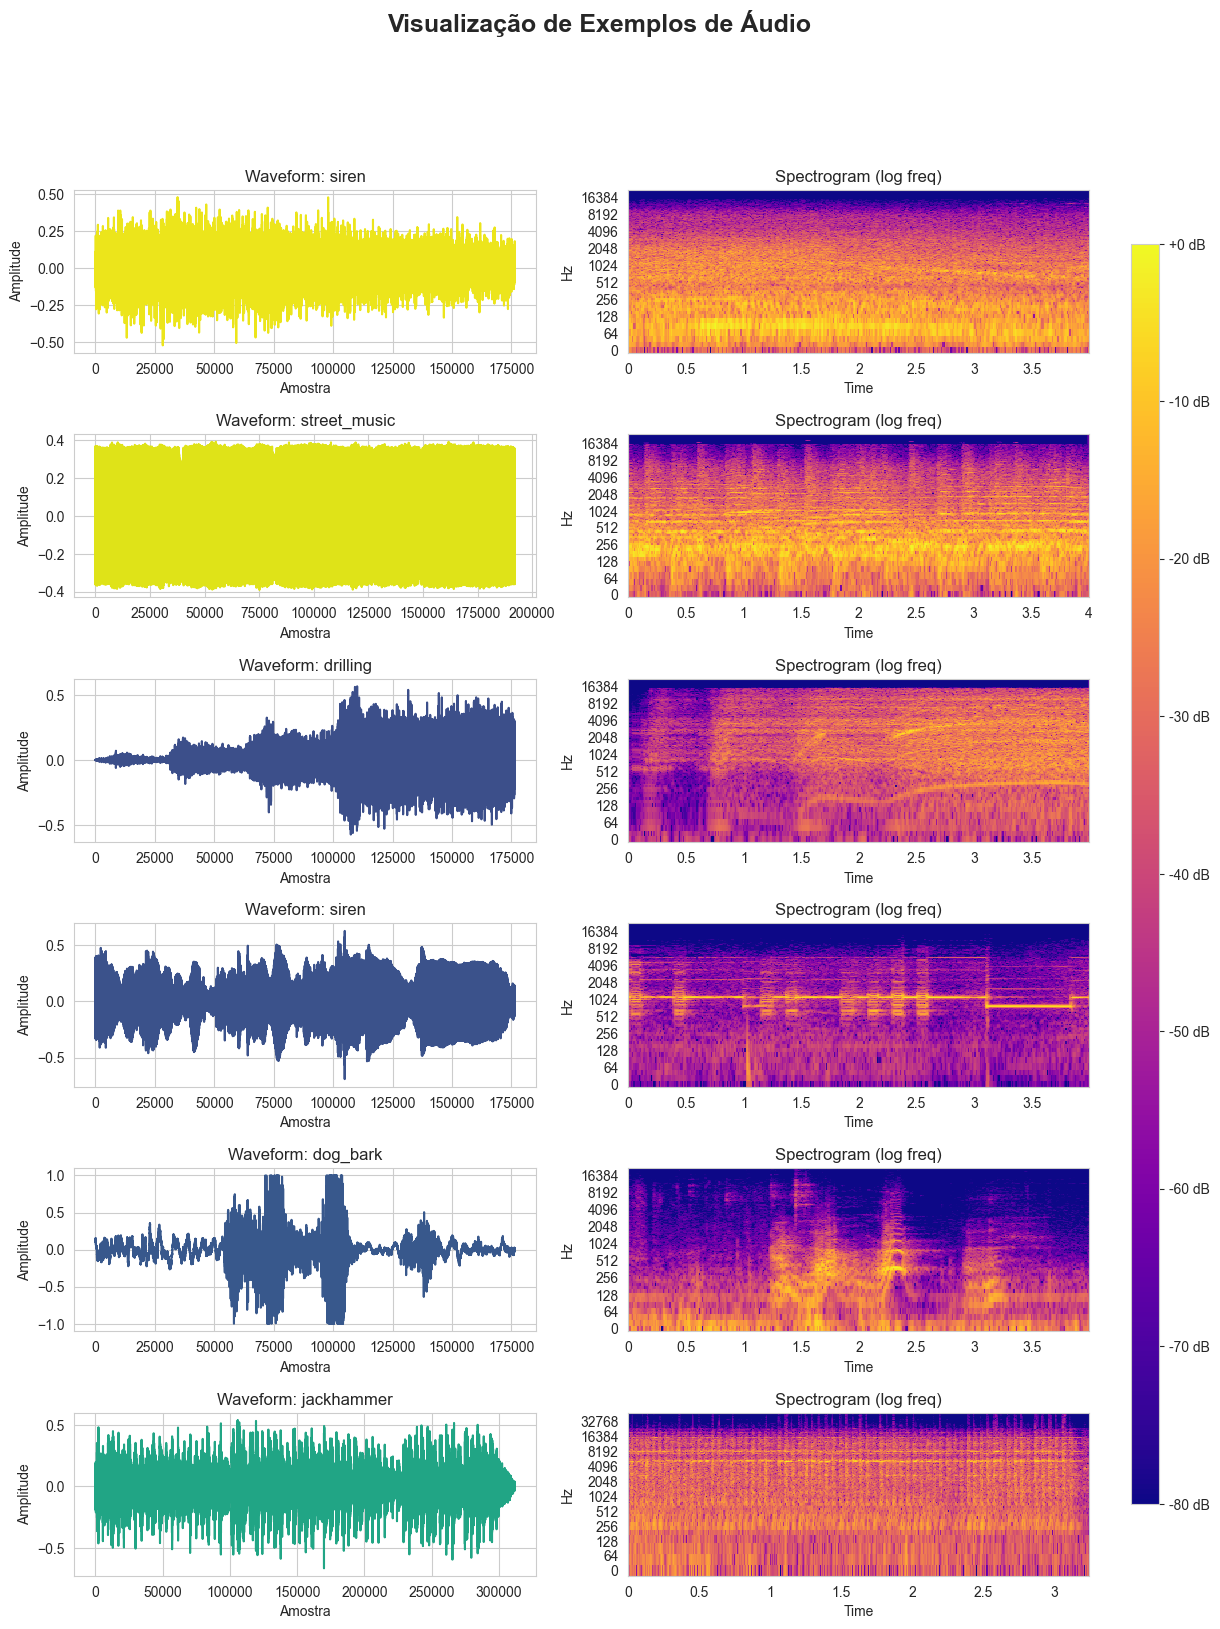

In [10]:
# Explorando múltiplos exemplos de áudio do dataset

import random
import librosa.display

# Selecionar 6 exemplos aleatórios do dataset
sample_rows = metadata.sample(6, random_state=42)

fig, axes = plt.subplots(6, 2, figsize=(14, 18))
fig.suptitle("Visualização de Exemplos de Áudio", fontsize=18, weight='bold')

for i, (_, row) in enumerate(sample_rows.iterrows()):
    file_path = os.path.join(dataset_path, f"fold{row['fold']}", row['slice_file_name'])
    waveform, sr = librosa.load(file_path, sr=None)
    
    # 🎨 Forma de onda com cor aleatória suave
    axes[i, 0].plot(waveform, color=plt.cm.viridis(random.random()))
    axes[i, 0].set_title(f"Waveform: {row['class']}", fontsize=12)
    axes[i, 0].set_xlabel("Amostra")
    axes[i, 0].set_ylabel("Amplitude")
    
    # 🔥 Espectrograma logarítmico
    S = librosa.stft(waveform)
    S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)
    img = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log', ax=axes[i, 1], cmap='plasma')
    axes[i, 1].set_title(f"Spectrogram (log freq)", fontsize=12)

# Ajuste de layout e colorbar
fig.subplots_adjust(right=0.85, hspace=0.5)
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
fig.colorbar(img, cax=cbar_ax, format='%+2.0f dB')

plt.show()


### Interpretação do Waveform e Spectrograma

- **Waveform**: Mostra a amplitude do som ao longo do tempo. Picos indicam sons mais intensos, vales indicam sons mais suaves ou silêncio.  
- **Spectrograma**: Representa a intensidade do som em diferentes frequências ao longo do tempo. Cores mais fortes indicam maior energia em determinada frequência.

**Como isso ajuda na extração de features**:  
- Permite identificar padrões relevantes de cada classe de som.  
- Indica quais frequências e trechos temporais contêm mais informação, essenciais para calcular features como MFCCs ou Mel-spectrogramas.  
- Ajuda a decidir pré-processamentos úteis, como normalização e data augmentation.


Sons com padrões visuais distintos (por exemplo, “dog_bark” vs “siren”) facilitam a classificação automática.
Visualmente, já se consegue perceber se uma classe de som tende a ter energia concentrada em certas frequências ou períodos de tempo, o que orienta a escolha das features.

## Preprocessamento de Dados

## 2- Data Augumentation

#### 2.1 - Uniformizar a duração dos clipes e a taxa de amostragem

#### Por que escolhemos 22.050 Hz como taxa de amostragem

A **taxa de amostragem** (*sample rate*) indica quantas amostras de áudio são capturadas por segundo. Ela determina tanto a **qualidade do áudio** quanto a **faixa de frequências que podemos registrar**.  

De acordo com o **Teorema de Nyquist**, a maior frequência que podemos capturar é **metade da taxa de amostragem**.  
No caso de 22.050 Hz:

Ou seja, todas as frequências até 11.025 Hz são preservadas.

### Por que isso é suficiente para modelos de aprendizado de máquina

- A maior parte das informações importantes em sons (como fala, instrumentos ou efeitos sonoros) está nas **frequências baixas e médias**, abaixo de 11 kHz.  
- Reduzir a taxa de amostragem de arquivos originalmente maiores (44.100 Hz, 48 kHz, etc.) **diminui o tamanho dos dados** sem perder os padrões relevantes.  
- Isso **facilita o processamento**, seja para CNNs, MLPs ou outros modelos.



#### 2.2- Duração

Redes neurais convolucionais (CNNs) precisam receber dados com **relação espacial consistente**.  

- Em imagens, mudar a ordem das linhas ou colunas altera a informação e destrói a estrutura original.  
- Da mesma forma, no áudio, a relação entre **frequências e amplitudes ao longo do tempo** é essencial.  

Um dataset com durações diferentes significa **vetores de entrada de tamanhos variados**, o que não é compatível com CNNs.  

**Solução:** usamos **padding**:  
- Para amostras menores que a duração máxima do dataset, preenchemos o restante com **zeros**.  
- Esta técnica é muito comum e **não prejudica o desempenho da rede**, permitindo que todas as amostras tenham o mesmo tamanho.


#### 2.3 - Amplitude Máxima

É importante **normalizar a amplitude** dos arquivos de áudio.  
Isso garante que o modelo aprenda **padrões de forma consistente**, sem ser influenciado apenas pelo volume do som, e evita problemas com saturação das funções de ativação.

#### 2.4 - Profundidade de Bits (Bit Depth)

A **profundidade de bits** define a **resolução de cada amostra de áudio**.  
- Maior bit depth → mais detalhes e maior faixa dinâmica.  
- Menor bit depth → menos precisão e mais ruído perceptível.  

Converter bit depths **não é problemático**, de forma semelhante à conversão da taxa de amostragem.


#### 2.5 - Mono

Para consistência no dataset, todos os arquivos são convertidos para **mono**.  
- Isso garante que cada amostra tenha **uma única forma de onda**, facilitando o processamento por qualquer modelo (MLP ou CNN).  
- Evita complicações com múltiplos canais que poderiam alterar os padrões de áudio que a rede aprende.


In [11]:

def load_mono_resample_and_fix(file_path, target_sr=22050, target_duration=4.0):
    target_length = int(target_sr * target_duration)
    
    # Carrega áudio, garante mono e faz resampling
    waveform, sr = librosa.load(file_path, sr=target_sr, mono=True)
    
    # Ajusta duração (padding ou corte)
    if len(waveform) < target_length:
        waveform = np.pad(waveform, (0, target_length - len(waveform)), mode='constant')
    else:
        waveform = waveform[:target_length]
    
    # Normaliza valores para [-1, 1]
    if np.max(np.abs(waveform)) > 0:
        waveform = waveform / np.max(np.abs(waveform))
    
    return waveform, sr


In [12]:
audio_data = []

for idx, row in tqdm(metadata.iterrows(), total=len(metadata)):
    file_path = os.path.join(dataset_path, f"fold{row['fold']}", row['slice_file_name'])
    
    # Carrega e processa áudio
    waveform, sr = load_mono_resample_and_fix(file_path, target_sr=22050, target_duration=4.0)
    duration = len(waveform) / sr
    
    # Adiciona ao dataset
    audio_data.append({
        "file": row['slice_file_name'],
        "fold": row['fold'],
        "class": row['class'],
        "waveform": waveform,
        "sr": sr,
        "duration": duration
    })

# Cria DataFrame final
audio_df = pd.DataFrame(audio_data)


100%|██████████| 8732/8732 [00:23<00:00, 364.15it/s]


In [13]:
print(audio_df.head())

print(audio_df.describe())

                 file  fold             class  \
0    100032-3-0-0.wav     5          dog_bark   
1  100263-2-0-117.wav     5  children_playing   
2  100263-2-0-121.wav     5  children_playing   
3  100263-2-0-126.wav     5  children_playing   
4  100263-2-0-137.wav     5  children_playing   

                                            waveform     sr  duration  
0  [-0.0035208412, -0.0050912397, -0.0047212285, ...  22050       4.0  
1  [0.10102415, 0.1341297, 0.085020825, 0.0867967...  22050       4.0  
2  [-0.1688533, -0.18749887, -0.099522546, -0.080...  22050       4.0  
3  [0.004630125, -0.0071468963, -0.041926064, -0....  22050       4.0  
4  [0.08385908, 0.28763315, 0.41862833, 0.3697775...  22050       4.0  
              fold       sr  duration
count  8732.000000   8732.0    8732.0
mean      5.385937  22050.0       4.0
std       2.846820      0.0       0.0
min       1.000000  22050.0       4.0
25%       3.000000  22050.0       4.0
50%       5.000000  22050.0       4.0
75%    

## 3.1 Extração de features para MLP


Um MLP espera vetores 1-D (fixos) por amostra. Como o áudio é uma sequência (tempo × frequência), transformamos cada clipe num vetor resumo de características que captem informação timbral e temporal (por exemplo: MFCCs agregados, energia, ZCR, centroid).

### 3.1.1 - Mel-Frequency Cepstral Coefficients (MFCCs)

#### MFCC deltas
Representam a *variação temporal* dos MFCCs, permitindo capturar mudanças dinâmicas no espectro.

#### Spectral centroid, bandwidth e rolloff
Medidas da forma espectral do áudio:

- *Centroid:* centro de massa do espectro (timbre).  
- *Bandwidth:* largura espectral.  
- *Rolloff:* frequência abaixo da qual 85% da energia espectral está contida.

#### RMS (Root Mean Square)
Mede a *energia do sinal*.

#### Zero-Crossing Rate (ZCR)
Mede a *frequência de cruzamento pelo zero* da onda, útil para textura ou percussão.

#### Spectral contrast
Mede a *diferença de energia entre picos e vales* no espectro, refletindo o conteúdo harmônico.

#### Chroma
Representa a *energia por classe de nota musical*, útil para sons musicais ou tons dominantes.

In [14]:
TARGET_SR = 22050
TARGET_DURATION = 4.0   # segundos
N_MFCC = 40
N_FFT = 2048
HOP_LENGTH = 512
RANDOM_STATE = 42


# Função: extrai features agregadas (1D vector) a partir de uma waveform
def extract_mlp_features(y, sr, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH):
    feats = []

    # MFCCs
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length)
    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std  = np.std(mfcc, axis=1)
    feats.extend(mfcc_mean)
    feats.extend(mfcc_std)

    # MFCC deltas
    mfcc_delta = librosa.feature.delta(mfcc)
    delta_mean = np.mean(mfcc_delta, axis=1)
    delta_std  = np.std(mfcc_delta, axis=1)
    feats.extend(delta_mean)
    feats.extend(delta_std)

    # Spectral centroid, bandwidth, rolloff (mean + std)
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    feats.append(np.mean(centroid)); feats.append(np.std(centroid))
    feats.append(np.mean(bandwidth)); feats.append(np.std(bandwidth))
    feats.append(np.mean(rolloff)); feats.append(np.std(rolloff))

    # RMS (energia) and ZCR (texture) - mean + std
    rms = librosa.feature.rms(y=y, frame_length=n_fft, hop_length=hop_length)
    zcr = librosa.feature.zero_crossing_rate(y, frame_length=n_fft, hop_length=hop_length)
    feats.append(np.mean(rms)); feats.append(np.std(rms))
    feats.append(np.mean(zcr)); feats.append(np.std(zcr))

    # Spectral contrast -> mean per band
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    feats.extend(np.mean(contrast, axis=1))

    # Chroma -> mean per bin
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    feats.extend(np.mean(chroma, axis=1))

    return np.array(feats, dtype=np.float32)

#### 3.1.2 Criação dos datasets das features

In [15]:
X_list = []
y_list = []

for idx, row in tqdm(audio_df.iterrows(), total=len(audio_df)):
    y = row["waveform"]     # áudio já preprocessado
    sr = row["sr"]          # sr já padronizado

    feat = extract_mlp_features(y, sr)
    X_list.append(feat)
    y_list.append(row["class"])

X = np.vstack(X_list)
y = np.array(y_list)

# Cria DataFrame com as features e a classe
feature_names = (
    [f"mfcc_mean_{i}" for i in range(N_MFCC)] +
    [f"mfcc_std_{i}" for i in range(N_MFCC)] +
    [f"delta_mean_{i}" for i in range(N_MFCC)] +
    [f"delta_std_{i}" for i in range(N_MFCC)] +
    ["centroid_mean", "centroid_std", "bandwidth_mean", "bandwidth_std", "rolloff_mean", "rolloff_std",
     "rms_mean", "rms_std", "zcr_mean", "zcr_std"] +
    [f"contrast_mean_{i}" for i in range(7)] +
    [f"chroma_mean_{i}" for i in range(12)]
)

MLP_features = pd.DataFrame(X, columns=feature_names)
MLP_features["class"] = y



100%|██████████| 8732/8732 [04:31<00:00, 32.11it/s]


In [16]:
# Exporta para CSV
MLP_features.to_csv("mlp_features.csv", index=False)
print("Features exportadas para mlp_features.csv")

Features exportadas para mlp_features.csv


## 3.2 Extração de Features para CNN

### 3.2.1 – Log-Mel Spectrograms

Para treinar uma CNN com áudio, cada waveform é convertida numa *imagem log-Mel*, permitindo que a rede aprenda padrões espectro-temporais.

#### Log-Mel Spectrogram
- Obtido aplicando FFT e projetando na escala Mel.
- Convertido para dB (log-Mel), destacando componentes espectrais relevantes.
- Padding/cropping é aplicado para garantir sempre o mesmo nº de frames.

#### Delta e Delta-Delta
- *Delta*: variação temporal (1ª derivada) do log-Mel.
- *Delta-Delta*: aceleração das mudanças (2ª derivada).
- Os três mapas formam um tensor 3D:  
  *(3 canais × N_MELS × N_FRAMES)*.

#### Pipeline
1. Padroniza waveform para 4s.  
2. Extrai log-Mel, delta e delta-delta.  
3. Empilha os 3 canais e guarda em .npz com seu classID.

#### Vantagem
Essa representação funciona como uma “imagem sonora”, permitindo à CNN aprender timbre, energia, transientes e padrões temporais de forma muito mais rica do que vetores 1D.


In [18]:
TARGET_SR = 22050
TARGET_DURATION = 4.0         # segundos (tu já usas 4s)
TARGET_LEN = int(TARGET_SR * TARGET_DURATION)  # 88200
N_FFT = 2048
HOP = 512
N_MELS = 128

# número de frames esperado na dimensão tempo
N_FRAMES = 1 + (TARGET_LEN - N_FFT) // HOP
print("EXPECTED MEL FRAMES (n_frames) =", N_FRAMES)   # deverá dar 169

# pasta onde guardar os ficheiros pré-computados
OUT_DIR = "precomputed_mels"
os.makedirs(OUT_DIR, exist_ok=True)


# === FUNÇÕES DE EXTRAÇÃO ===
def waveform_to_log_mel(y, sr=TARGET_SR, n_fft=N_FFT, hop_length=HOP, n_mels=N_MELS, frames_max=N_FRAMES):
    """
    Recebe uma waveform (mono, resampled, padded/cropped para TARGET_LEN) e devolve S_db (n_mels, n_frames)
    com padding temporal central se necessário.
    """
    # assegura tipo float
    y = np.asarray(y, dtype=np.float32)
    # calcula mel power spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels, power=2.0)
    # converte para dB (log-mel)
    S_db = librosa.power_to_db(S, ref=np.max)
    # se for mais curto em frames, aplica padding central
    if frames_max is not None and S_db.shape[1] < frames_max:
        diff = frames_max - S_db.shape[1]
        left = diff // 2
        right = diff - left
        S_db = np.pad(S_db, pad_width=((0,0),(left,right)), mode='constant', constant_values=(S_db.min(),))
    # se por algum motivo for maior: corta centralmente (não esperado se as waveforms já estão pad/crop)
    if frames_max is not None and S_db.shape[1] > frames_max:
        start = (S_db.shape[1] - frames_max)//2
        S_db = S_db[:, start:start+frames_max]
    return S_db.astype(np.float32)


def build_stack_from_waveform(y, sr=TARGET_SR, n_fft=N_FFT, hop_length=HOP, n_mels=N_MELS, frames_max=N_FRAMES):
    """
    Retorna stack numpy (3, n_mels, n_frames): [log-mel, delta1, delta2]
    """
    mel = waveform_to_log_mel(y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels, frames_max=frames_max)
    d1 = librosa.feature.delta(mel)
    d2 = librosa.feature.delta(mel, order=2)
    stacked = np.stack([mel, d1, d2], axis=0).astype(np.float32)
    return stacked


# === PIPELINE: usa audio_df (que tu já tens) e guarda .npz ===
# audio_df deve ter colunas: 'file' (slice_file_name), 'fold', 'class' (nome) e 'waveform', 'sr'
# metadata tem classID; vamos obter classID a partir do metadata dataframe
# Assumo que 'metadata' existe (tal como no teu notebook)

def precompute_and_save_npz(audio_df, metadata_df, out_dir=OUT_DIR, frames_max=N_FRAMES):
    """
    Extrai log-mel+delta+delta2 para cada linha de audio_df (usando waveform salvo aí) e guarda .npz.
    """
    missing = 0
    for i, row in tqdm(audio_df.iterrows(), total=len(audio_df), desc="precompute"):
        file_name = row['file']    # ex: '100032-3-0-0.wav'
        fold = int(row['fold'])
        # obtém classID do metadata (match por file e fold)
        m = metadata_df[(metadata_df['slice_file_name']==file_name) & (metadata_df['fold']==fold)]
        if len(m) == 0:
            # fallback: procura só pelo file (caso nomes diferentes)
            m = metadata_df[metadata_df['slice_file_name']==file_name]
        if len(m) == 0:
            missing += 1
            continue
        classID = int(m['classID'].values[0])
        # waveform já tem resample e padding (se tens audio_df)
        y = row['waveform']
        # sanity check length; se não tiveres pad, podes chamar load_mono_resample_and_fix aqui
        if len(y) != TARGET_LEN:
            # corrige automaticamente: pad ou crop
            if len(y) < TARGET_LEN:
                y = np.pad(y, (0, TARGET_LEN - len(y)), mode='constant')
            else:
                y = y[:TARGET_LEN]
        # constrói stack e salva
        stacked = build_stack_from_waveform(y, sr=TARGET_SR, frames_max=frames_max)
        base = f"fold{fold}_{file_name.replace('.wav','')}.npz"
        np.savez_compressed(os.path.join(out_dir, base), arr=stacked, classID=classID)
    if missing>0:
        print(f"Warning: {missing} rows not matched to metadata (verifica nomes/folds).")
    print("Done. Saved to", out_dir)


# === UTIL: check e visualizar um exemplo ===
def sanity_check_and_visualize(out_dir=OUT_DIR, example_idx=0):
    files = sorted([f for f in os.listdir(out_dir) if f.endswith('.npz')])
    if len(files)==0:
        print("No .npz files found in", out_dir); return
    p = os.path.join(out_dir, files[example_idx])
    data = np.load(p)
    arr = data['arr']   # (3, n_mels, n_frames)
    cls = int(data['classID'])
    print("Loaded:", files[example_idx], "shape:", arr.shape, "classID:", cls)
    plt.figure(figsize=(10,4))
    librosa.display.specshow(arr[0], sr=TARGET_SR, hop_length=HOP, x_axis='time', y_axis='mel')
    plt.title(f"Log-Mel (example) - {files[example_idx]}")
    plt.colorbar(format='%+2.0f dB')
    plt.tight_layout()
    plt.show()



EXPECTED MEL FRAMES (n_frames) = 169


In [19]:
precompute_and_save_npz(audio_df, metadata, out_dir=OUT_DIR, frames_max=N_FRAMES)

precompute: 100%|██████████| 8732/8732 [02:01<00:00, 71.86it/s] 

Done. Saved to precomputed_mels


Loaded: fold10_157207-6-1-0.npz shape: (3, 128, 169) classID: 6


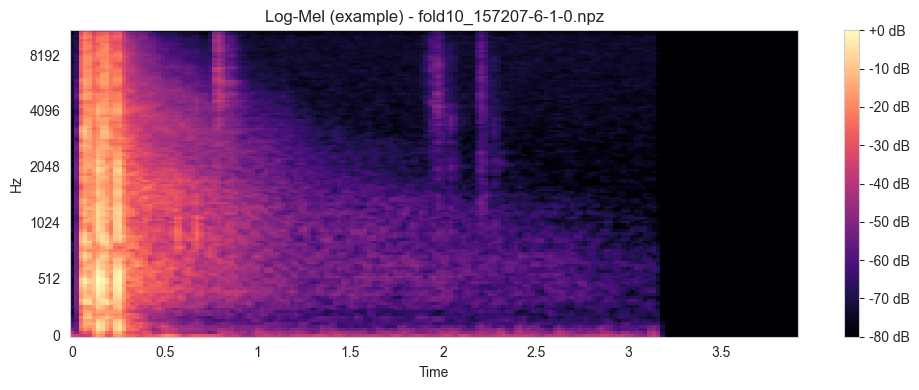

In [35]:
sanity_check_and_visualize(OUT_DIR, example_idx=200)

Referências:

- [Environmental sound classification with convolutional neural networks](https://ieeexplore.ieee.org/abstract/document/7324337)


In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_all)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão')
plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista')
plt.show()

# CNN

## 1. Carregar dados

In [4]:
def get_files_by_fold(base_path, fold):
    """Retorna lista de ficheiros .npz de um fold específico"""
    pattern = os.path.join(base_path, f"fold{fold}_*.npz")
    files = glob.glob(pattern)
    return sorted(files)

def get_train_files(base_path, exclude_folds):
    """Retorna ficheiros de treino (todos exceto os folds excluídos)"""
    all_files = []
    for fold in range(1, 11):  # folds 1-10
        if fold not in exclude_folds:
            all_files.extend(get_files_by_fold(base_path, fold))
    return sorted(all_files)

def load_npz_tf(path):
    def _load(npz_path):
        # Converte tensor para string Python
        path_str = npz_path.numpy().decode('utf-8') if isinstance(npz_path, bytes) else npz_path.numpy()
        data = np.load(path_str, allow_pickle=False)
        arr = data['arr'].astype(np.float16)          # (3,128,169)
        arr = np.transpose(arr, (1,2,0))              # (128,169,3)
        y = data['classID'].astype(np.int32)
        return arr, y
    
    arr, y = tf.py_function(_load, [path], [tf.float16, tf.int32])
    arr.set_shape((128,169,3))
    y.set_shape(())
    return arr, y

def make_ds(files, batch=4, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices(files)
    if shuffle:
        ds = ds.shuffle(buffer_size=min(len(files), 1000))
    ds = ds.map(load_npz_tf, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds

In [5]:
import glob

# Configuração dos folds
VAL_FOLD = 10
TEST_FOLD = 9

# Construir listas de ficheiros .npz
AUDIO_PATH = "./precomputed_mels"

# Criar as listas
train_files = get_train_files(AUDIO_PATH, exclude_folds=[VAL_FOLD, TEST_FOLD])
val_files = get_files_by_fold(AUDIO_PATH, VAL_FOLD)
test_files = get_files_by_fold(AUDIO_PATH, TEST_FOLD)

print(f"Train: {len(train_files)} ficheiros")
print(f"Val:   {len(val_files)} ficheiros")
print(f"Test:  {len(test_files)} ficheiros")

train_ds = make_ds(train_files, batch=4, shuffle=True)
val_ds   = make_ds(val_files, batch=4, shuffle=False)
test_ds  = make_ds(test_files, batch=4, shuffle=False)

mixed_precision.set_global_policy('mixed_float16')

sample_x, _ = next(iter(train_ds))


Train: 7079 ficheiros
Val:   837 ficheiros
Test:  816 ficheiros


I0000 00:00:1764533386.042554  344940 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1702 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


## 2. Modelos CNN 2D

### 2.1 Modelo com 2 Layers Conv2D

In [6]:
def cnn2d_model_2_layers(num_classes=10, base=8, padding='same', activation='relu', output_activation='softmax'):
    model = tf.keras.Sequential()
    model.add(layers.Conv2D(base, 3, padding=padding, activation=activation))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2))
    model.add(layers.Conv2D(base*2, 3, padding=padding, activation=activation))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2))
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(base*4, activation=activation))
    model.add(layers.Dropout(0.4))
    model.add(layers.Dense(num_classes, activation=output_activation, dtype='float32'))
    return model

#### Teste de modelo

In [7]:
model = cnn2d_model_2_layers(num_classes=10, base=8, padding='same', activation='relu', output_activation='softmax')
model.build(sample_x.shape)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    batch_size=16,
    epochs=100,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5)
    ]
)

y_true = []
y_pred_all = []
for x_batch, y_batch in test_ds:
    y_true.extend(y_batch.numpy())
    y_pred_batch = model.predict(x_batch, verbose=0)
    y_pred_all.extend(np.argmax(y_pred_batch, axis=1))

y_true = np.array(y_true)
y_pred_all = np.array(y_pred_all)
print(classification_report(y_true, y_pred_all, digits=4))

# plot training history
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['loss','test_loss'], loc='upper left')
plt.show()

# Evaluate the model

scores = model.evaluate(test_ds)
print("Test accuracy:",scores[1])

scores = model.evaluate(val_ds)
print("Val accuracy:",scores[1])

Epoch 1/100


2025-11-30 20:09:50.166843: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f0094010700 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-11-30 20:09:50.166855: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Laptop GPU, Compute Capability 8.6
2025-11-30 20:09:50.217290: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-11-30 20:09:50.492537: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


  31/1770 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.1344 - loss: 2.5232

I0000 00:00:1764533396.703349  345353 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 304/1770 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.1359 - loss: 2.4461

KeyboardInterrupt: 

### 2.2 Modelo com 3 layers Conv2D

In [ ]:
def cnn2d_model_3_layers(num_classes=10, base=8, padding='same', activation='relu', output_activation='softmax'):
    model = tf.keras.models.Sequential()
    model.add(layers.Conv2D(base, 3, padding=padding, activation=activation))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2))
    model.add(layers.Conv2D(base*2, 3, padding=padding, activation=activation))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2))
    model.add(layers.Conv2D(base*4, 3, padding=padding, activation=activation))
    model.add(layers.BatchNormalization())
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(base*8, activation=activation))
    model.add(layers.Dropout(0.4))
    model.add(layers.Dense(num_classes, activation=output_activation))
    return model

#### Teste de modelo

In [ ]:
model = cnn2d_model_3_layers(num_classes=10, base=8, padding='same', activation='relu', output_activation='softmax')
model.build(sample_x.shape)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    batch_size=16,
    epochs=100,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5)
    ]
)

y_true = []
y_pred_all = []
for x_batch, y_batch in test_ds:
    y_true.extend(y_batch.numpy())
    y_pred_batch = model.predict(x_batch, verbose=0)
    y_pred_all.extend(np.argmax(y_pred_batch, axis=1))

y_true = np.array(y_true)
y_pred_all = np.array(y_pred_all)
print(classification_report(y_true, y_pred_all, digits=4))

# plot training history
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['loss','test_loss'], loc='upper left')
plt.show()

# Evaluate the model

scores = model.evaluate(test_ds)
print("Test accuracy:",scores[1])

scores = model.evaluate(val_ds)
print("Val accuracy:",scores[1])

### 2.3 Modelo com 4 layers Conv2D

In [8]:
def cnn2d(num_classes=10, base=8, padding='same', activation='relu', output_activation='softmax'):
    model = tf.keras.models.Sequential()
    model.add(layers.Conv2D(base, 3, padding=padding, activation=activation))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2))
    model.add(layers.Conv2D(base*2, 3, padding=padding, activation=activation))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2))
    model.add(layers.Conv2D(base*4, 3, padding=padding, activation=activation))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2))
    model.add(layers.Conv2D(base*8, 3, padding=padding, activation=activation))
    model.add(layers.BatchNormalization())
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(base*16, activation=activation))
    model.add(layers.Dropout(0.4))
    model.add(layers.Dense(num_classes, activation=output_activation))
    return model

#### Teste de modelo 

In [ ]:
model = cnn2d(num_classes=10, base=8, padding='same', activation='relu', output_activation='softmax')
model.build(sample_x.shape)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    batch_size=16,
    epochs=100,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5)
    ]
)

y_true = []
y_pred_all = []
for x_batch, y_batch in test_ds:
    y_true.extend(y_batch.numpy())
    y_pred_batch = model.predict(x_batch, verbose=0)
    y_pred_all.extend(np.argmax(y_pred_batch, axis=1))

y_true = np.array(y_true)
y_pred_all = np.array(y_pred_all)
print(classification_report(y_true, y_pred_all, digits=4))

# plot training history
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['loss','test_loss'], loc='upper left')
plt.show()

# Evaluate the model

scores = model.evaluate(test_ds)
print("Test accuracy:",scores[1])

scores = model.evaluate(val_ds)
print("Val accuracy:",scores[1])

### 2.4 Modelo com 5 layers Conv2D

In [ ]:
def cnn2d_model_5_layers(num_classes=10, base=8, padding='same', activation='relu', output_activation='softmax'):
    model = tf.keras.models.Sequential()
    model.add(layers.Conv2D(base, 3, padding=padding, activation=activation))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2))
    model.add(layers.Conv2D(base*2, 3, padding=padding, activation=activation))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2))
    model.add(layers.Conv2D(base*4, 3, padding=padding, activation=activation))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2))
    model.add(layers.Conv2D(base*8, 3, padding=padding, activation=activation))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D(2))
    model.add(layers.Conv2D(base*16, 3, padding=padding, activation=activation))
    model.add(layers.BatchNormalization())
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(base*32, activation=activation))
    model.add(layers.Dropout(0.4))
    model.add(layers.Dense(num_classes, activation=output_activation))
    return model

#### Teste de modelo

In [ ]:
model = cnn2d_model_5_layers(num_classes=10, base=8, padding='same', activation='relu', output_activation='softmax')
model.build(sample_x.shape)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    batch_size=16,
    epochs=100,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5)
    ]
)

y_true = []
y_pred_all = []
for x_batch, y_batch in test_ds:
    y_true.extend(y_batch.numpy())
    y_pred_batch = model.predict(x_batch, verbose=0)
    y_pred_all.extend(np.argmax(y_pred_batch, axis=1))

y_true = np.array(y_true)
y_pred_all = np.array(y_pred_all)
print(classification_report(y_true, y_pred_all, digits=4))

# plot training history
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['loss','test_loss'], loc='upper left')
plt.show()

# Evaluate the model

scores = model.evaluate(test_ds)
print("Test accuracy:",scores[1])

scores = model.evaluate(val_ds)
print("Val accuracy:",scores[1])

Overfiting - treinando com menor learning rate

In [ ]:
model = cnn2d_model_5_layers(num_classes=10, base=8, padding='same', activation='relu', output_activation='softmax')
model.build(sample_x.shape)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    batch_size=16,
    epochs=100,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5)
    ]
)

y_true = []
y_pred_all = []
for x_batch, y_batch in test_ds:
    y_true.extend(y_batch.numpy())
    y_pred_batch = model.predict(x_batch, verbose=0)
    y_pred_all.extend(np.argmax(y_pred_batch, axis=1))

y_true = np.array(y_true)
y_pred_all = np.array(y_pred_all)
print(classification_report(y_true, y_pred_all, digits=4))

# plot training history
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['loss','test_loss'], loc='upper left')
plt.show()

# Evaluate the model

scores = model.evaluate(test_ds)
print("Test accuracy:",scores[1])

scores = model.evaluate(val_ds)
print("Val accuracy:",scores[1])

A melhor CNN é a chamada cnn2d que tem 4 layers Conv2D. Apresenta melhor accuracy do que as CNNs com menos layers (70% > 58% > 49%). O modelo com 5 layers têm tendencia a overfitting, mesmo com um learning rate menor, sendo o modelo de 4 layers não apresenta esse problema.

### Testar diferentes configurações para melhor modelo

In [ ]:

import itertools
import pandas as pd
from tqdm import trange

def test_cnn2d_variants(train_ds, val_ds, sample_x,
                        paddings=('same','valid'),
                        activations=('relu','elu','selu','swish'),
                        output_activations=('softmax','sigmoid'),
                        base=8,
                        lr=1e-4,
                        epochs=5,
                        steps_per_epoch=None,
                        validation_steps=None):
    """
    Treina rapidamente modelos CNN2D com combinações e retorna resumo.
    - train_ds, val_ds: tf.data.Dataset
    - sample_x: tensor para build() (ex: sample_x.shape)
    - steps_per_epoch / validation_steps: se quiser limitar a execução rápida
    """
    results = []
    combos = list(itertools.product(paddings, activations, output_activations))
    for padding, activation, out_act in tqdm(combos, desc="combos"):
        tf.keras.backend.clear_session()
        try:
            model = cnn2d(num_classes=10, base=base, padding=padding,
                          activation=activation, output_activation=out_act)
            model.build(sample_x.shape)
            model.compile(
                optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy']
            )
            # fit (rápido): limitar steps se fornecido para testes
            fit_kwargs = dict(epochs=epochs, validation_data=val_ds, verbose=0)
            if steps_per_epoch is not None:
                fit_kwargs['steps_per_epoch'] = steps_per_epoch
            if validation_steps is not None:
                fit_kwargs['validation_steps'] = validation_steps

            history = model.fit(train_ds, **fit_kwargs)
            # extrair métricas finais
            val_loss = history.history.get('val_loss', [None])[-1]
            val_acc = history.history.get('val_accuracy', history.history.get('val_acc', [None]))[-1]
            train_loss = history.history.get('loss', [None])[-1]
            train_acc = history.history.get('accuracy', history.history.get('acc', [None]))[-1]

            results.append({
                'padding': padding,
                'activation': activation,
                'output_activation': out_act,
                'train_loss': float(train_loss) if train_loss is not None else None,
                'train_acc': float(train_acc) if train_acc is not None else None,
                'val_loss': float(val_loss) if val_loss is not None else None,
                'val_acc': float(val_acc) if val_acc is not None else None
            })
        except Exception as e:
            results.append({
                'padding': padding,
                'activation': activation,
                'output_activation': out_act,
                'error': str(e)
            })
    df = pd.DataFrame(results)
    df = df.sort_values(by='val_acc', ascending=False, na_position='last').reset_index(drop=True)
    return df

# executa poucas steps para acelerar os testes
summary = test_cnn2d_variants(
    train_ds=train_ds,
    val_ds=val_ds,
    sample_x=sample_x,
    paddings=('same','valid'),
    activations=('relu','elu','selu','swish'),
    output_activations=('softmax','sigmoid'),
    base=8,
    lr=1e-4,
    epochs=10,
    steps_per_epoch=300,      # remover ou aumentar para treino completo
    validation_steps=10
)

print(summary)
# Guardar resumo
summary.to_csv("cnn2d_variants_summary.csv", index=False)


A melhor combinação para o modelo é de valid, selu e  softmax, e de valid, swish, sigmoid. A escolhida foi a de valid, selu e softmax uma vez que apresentam um relativamente uma menor loss e melhor accuracy de treino

In [10]:
padd = 'same'
act = 'relu'
out_act = 'softmax'

## 3. Modelo Final

Epoch 1/100
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - accuracy: 0.2664 - loss: 2.0219 - val_accuracy: 0.4373 - val_loss: 1.5992 - learning_rate: 5.0000e-05
Epoch 2/100
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.3421 - loss: 1.7945 - val_accuracy: 0.4791 - val_loss: 1.4377 - learning_rate: 5.0000e-05
Epoch 3/100
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.3995 - loss: 1.6562 - val_accuracy: 0.5006 - val_loss: 1.3280 - learning_rate: 5.0000e-05
Epoch 4/100
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.4359 - loss: 1.5504 - val_accuracy: 0.5974 - val_loss: 1.2213 - learning_rate: 5.0000e-05
Epoch 5/100
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.4680 - loss: 1.4743 - val_accuracy: 0.5806 - val_loss: 1.1768 - learning_rate: 5.0000e-05
Epoch 6/100
1770/1770 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.4936 - loss: 1.4176 - val_accuracy: 0.6368 - val_loss: 1.1015 - learning_rate: 5.0000e-05
Epoch 7/100
1770/1770 ━━━━━━━━━━━━━━━━━

2025-11-30 20:18:34.790194: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


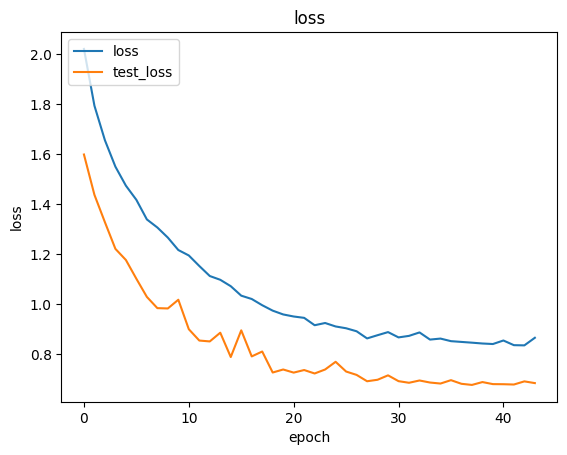

204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7672 - loss: 0.8170
Test accuracy: 0.7671568393707275
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7682 - loss: 0.6765
Val accuracy: 0.7682198286056519


In [11]:
model = cnn2d(num_classes=10, base=8, padding=padd, activation=act, output_activation=out_act)
model.build(sample_x.shape)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    batch_size=16,
    epochs=100,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5)
    ]
)

y_true = []
y_pred_all = []
for x_batch, y_batch in test_ds:
    y_true.extend(y_batch.numpy())
    y_pred_batch = model.predict(x_batch, verbose=0)
    y_pred_all.extend(np.argmax(y_pred_batch, axis=1))

y_true = np.array(y_true)
y_pred_all = np.array(y_pred_all)
print(classification_report(y_true, y_pred_all, digits=4))

# plot training history
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['loss','test_loss'], loc='upper left')
plt.show()

# Evaluate the model

scores = model.evaluate(test_ds)
print("Test accuracy:",scores[1])

scores = model.evaluate(val_ds)
print("Val accuracy:",scores[1])

                  precision   recall  f1-score  support
air_conditioner    0.542857  0.19000  0.281481    100.0
car_horn           0.771429  0.84375  0.805970     32.0
children_playing   0.877778  0.79000  0.831579    100.0
dog_bark           0.622951  0.76000  0.684685    100.0
drilling           0.752809  0.67000  0.708995    100.0


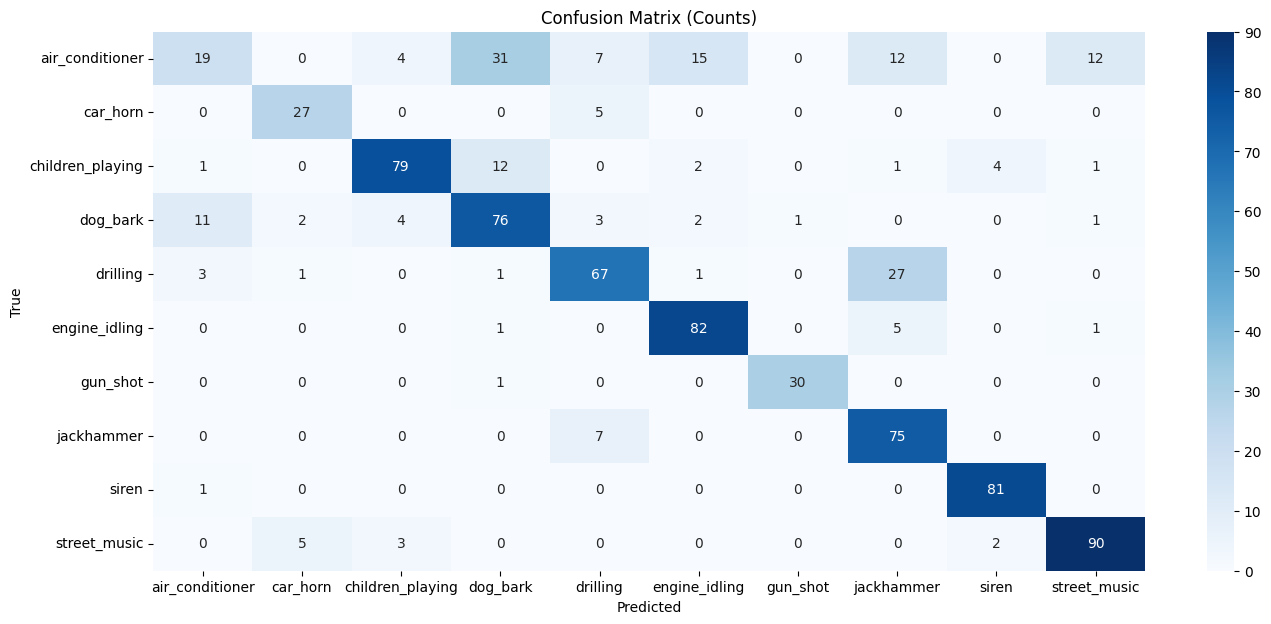

In [27]:
class_names = [
    "air_conditioner","car_horn","children_playing","dog_bark","drilling",
    "engine_idling","gun_shot","jackhammer","siren","street_music"
]

cm = confusion_matrix(y_true, y_pred_all, labels=range(10))

report_df = pd.DataFrame(classification_report(y_true, y_pred_all, target_names=class_names, output_dict=True)).T
print(report_df.head())

fig, axes = plt.subplots(1, 1, figsize=(16, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=axes)
axes.set_title('Confusion Matrix (Counts)')
axes.set_xlabel('Predicted')
axes.set_ylabel('True')
plt.show()

Como é possível ver, a cnn tem grande dificuldade a identificar air_conditioner. Mas apresenta muita facilidade em identificar gun_shot, children_playing e siren

## 4. K-fold cross-validation

In [ ]:
os.makedirs("./models", exist_ok=True)

def k_fold_run(k=10, batch_size=16, base=8, lr=5e-5, epochs=1000, patience_es=6, patience_rlr=3, save_best=False):
    results = []
    for test_fold in range(1, k+1):
        val_fold = (test_fold % k) + 1
        print(f"\n=== Fold {test_fold}/{k} — Test=fold{test_fold} Val=fold{val_fold} ===")

        # ficheiros
        train_files = get_train_files(AUDIO_PATH, exclude_folds=[val_fold, test_fold])
        val_files = get_files_by_fold(AUDIO_PATH, val_fold)
        test_files = get_files_by_fold(AUDIO_PATH, test_fold)

        print(f"Train files: {len(train_files)}  Val files: {len(val_files)}  Test files: {len(test_files)}")

        # datasets (recria para cada fold)
        train_ds_fold = make_ds(train_files, batch=batch_size, shuffle=True)
        val_ds_fold   = make_ds(val_files, batch=batch_size, shuffle=False)
        test_ds_fold  = make_ds(test_files, batch=batch_size, shuffle=False)

        # treinar
        tf.keras.backend.clear_session()

        model = cnn2d(num_classes=10, base=base, padding='valid', activation='selu', output_activation='softmax')
        model.build(sample_x.shape)
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )

        callbacks = [
            tf.keras.callbacks.EarlyStopping(patience=patience_es, restore_best_weights=True, verbose=1),
            tf.keras.callbacks.ReduceLROnPlateau(patience=patience_rlr, factor=0.5, verbose=1)
        ]
        if save_best:
            ckpt = tf.keras.callbacks.ModelCheckpoint(f"best_fold{test_fold}.h5", save_best_only=True, verbose=1)
            callbacks.append(ckpt)

        history = model.fit(
            train_ds_fold,
            validation_data=val_ds_fold,
            epochs=epochs,
            batch_size=batch_size,   # dataset já está batchado; pode ser omitido
            callbacks=callbacks,
            verbose=1
        )

        # avaliar no test set
        test_loss, test_acc = model.evaluate(test_ds_fold, verbose=1)

        # métricas do melhor epoch na validação
        val_accs = history.history.get('val_accuracy', history.history.get('val_acc', []))
        val_losses = history.history.get('val_loss', [])
        best_val_acc = float(np.max(val_accs)) if len(val_accs)>0 else None
        best_val_loss = float(np.min(val_losses)) if len(val_losses)>0 else None

        results.append({
            'fold': test_fold,
            'val_fold': val_fold,
            'test_loss': float(test_loss),
            'test_acc': float(test_acc),
            'best_val_loss': best_val_loss,
            'best_val_acc': best_val_acc,
            'train_samples': len(train_files),
            'val_samples': len(val_files),
            'test_samples': len(test_files)
        })
        
        model.save(f"./models/cnn2d_fold{test_fold}.keras")

    df = pd.DataFrame(results).sort_values('fold').reset_index(drop=True)
    print("\nK-Fold results:")
    print(df)
    print(f"\nMean test acc: {df['test_acc'].mean():.4f} ± {df['test_acc'].std():.4f}")
    return df

# Executar (ajusta batch_size / epochs conforme recursos)
kf_results = k_fold_run(k=10, batch_size=16, base=8, lr=0.00005, epochs=1000, patience_es=6, patience_rlr=3, save_best=False)
kf_results.to_csv("kfold_results_CNN2D_base8.csv", index=False)

# MLP

#### Integração das Features para o MLP com a Metadata

In [20]:
# Adiciona coluna 'file' ao MLP_features
MLP_features['file'] = audio_df['file'].values  

# Faz merge apenas UMA vez para adicionar 'fold' e 'classID'
MLP_features = MLP_features.merge(
    metadata[['slice_file_name', 'fold', 'classID']],
    left_on='file', right_on='slice_file_name', how='left'
)

# Renomeia todas as colunas auxiliares para nomes únicos e consistentes
for df in [MLP_features]:
    for col in df.columns:
        if col.startswith('fold'):
            df.rename(columns={col: 'fold'}, inplace=True)
        if col.startswith('classID'):
            df.rename(columns={col: 'classID'}, inplace=True)
        if col.startswith('slice_file_name'):
            df.rename(columns={col: 'slice_file_name'}, inplace=True)

# Remove colunas auxiliares do merge
MLP_features = MLP_features.drop(columns=['slice_file_name'])

# Remove colunas duplicadas se existirem 
MLP_features = MLP_features.loc[:, ~MLP_features.columns.duplicated()]


In [21]:
print(MLP_features.columns)
print(MLP_features.head())

Index(['mfcc_mean_0', 'mfcc_mean_1', 'mfcc_mean_2', 'mfcc_mean_3',
       'mfcc_mean_4', 'mfcc_mean_5', 'mfcc_mean_6', 'mfcc_mean_7',
       'mfcc_mean_8', 'mfcc_mean_9',
       ...
       'chroma_mean_6', 'chroma_mean_7', 'chroma_mean_8', 'chroma_mean_9',
       'chroma_mean_10', 'chroma_mean_11', 'class', 'file', 'fold', 'classID'],
      dtype='object', length=193)
   mfcc_mean_0  mfcc_mean_1  mfcc_mean_2  mfcc_mean_3  mfcc_mean_4  \
0  -590.823181     5.574052   -10.476468    -5.272372    -1.054818   
1   -62.527626    99.336624   -42.995586    51.073326     9.853778   
2   -46.742538   112.362534   -37.578072    43.195866     8.631845   
3   -69.774872    91.196602   -25.043556    42.784519    11.586844   
4   -26.328707   103.862228   -42.658787    50.690285    12.209422   

   mfcc_mean_5  mfcc_mean_6  mfcc_mean_7  mfcc_mean_8  mfcc_mean_9  ...  \
0    -2.363346    -0.301927     1.025405     1.102500     0.668602  ...   
1     7.969693    11.197088     1.929118     7.030397     

## Feature Selection MLP
#### No caso do CNN, não é recomendado fazer um feature selection previamente ao treino como no caso do MLP, porque o objetivo do CNN é justamente aprender automaticamente as melhores features a partir do espectrograma completo (ou seja, da matriz 3×128×169), se não a estrutura espacial/temporal dos dados seria eliminada.

#### Começamos por fazer um estudo das features extraidas para o MLP

In [22]:
feature_cols = [col for col in MLP_features.columns if col not in ["class", "file", "fold", "classID"]]
X = MLP_features[feature_cols]
y = MLP_features["class"]

# Verifica colunas com qualquer valor NaN
nan_cols = X.columns[X.isna().any()].tolist()
if nan_cols:
    print("Colunas com NaN:", nan_cols)
else:
    print("Nenhuma coluna com NaN.")

# Verifica colunas com valores constantes (variância zero)
const_cols = [col for col in X.columns if X[col].nunique() == 1]
if const_cols:
    print("Colunas com valor constante:", const_cols)
else:
    print("Nenhuma coluna com valor constante.")

# 2. Remover features com variância muito baixa (não informativas)
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold(threshold=1e-5)
X_reduced = selector.fit_transform(X)
selected_columns = X.columns[selector.get_support(indices=True)]
removed_columns = X.columns[~selector.get_support()]

print("Colunas removidas por baixa variância:", list(removed_columns))
print("Shape após VarianceThreshold:", X_reduced.shape)
print("Features selecionadas:", list(selected_columns))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[selected_columns])

Nenhuma coluna com NaN.
Nenhuma coluna com valor constante.
Colunas removidas por baixa variância: []
Shape após VarianceThreshold: (8732, 189)
Features selecionadas: ['mfcc_mean_0', 'mfcc_mean_1', 'mfcc_mean_2', 'mfcc_mean_3', 'mfcc_mean_4', 'mfcc_mean_5', 'mfcc_mean_6', 'mfcc_mean_7', 'mfcc_mean_8', 'mfcc_mean_9', 'mfcc_mean_10', 'mfcc_mean_11', 'mfcc_mean_12', 'mfcc_mean_13', 'mfcc_mean_14', 'mfcc_mean_15', 'mfcc_mean_16', 'mfcc_mean_17', 'mfcc_mean_18', 'mfcc_mean_19', 'mfcc_mean_20', 'mfcc_mean_21', 'mfcc_mean_22', 'mfcc_mean_23', 'mfcc_mean_24', 'mfcc_mean_25', 'mfcc_mean_26', 'mfcc_mean_27', 'mfcc_mean_28', 'mfcc_mean_29', 'mfcc_mean_30', 'mfcc_mean_31', 'mfcc_mean_32', 'mfcc_mean_33', 'mfcc_mean_34', 'mfcc_mean_35', 'mfcc_mean_36', 'mfcc_mean_37', 'mfcc_mean_38', 'mfcc_mean_39', 'mfcc_std_0', 'mfcc_std_1', 'mfcc_std_2', 'mfcc_std_3', 'mfcc_std_4', 'mfcc_std_5', 'mfcc_std_6', 'mfcc_std_7', 'mfcc_std_8', 'mfcc_std_9', 'mfcc_std_10', 'mfcc_std_11', 'mfcc_std_12', 'mfcc_std_13', 'm

### Ranking e Seleção de Features para o dataset de treino com recurso ao ANOVA F-Test

### Cálculo dos F-scores e p-values
O método f_classif calcula:

- *F-score* → mede separabilidade entre classes  
- *p-value* → mede significância estatística

In [23]:
# ANOVA F-test
f_values, p_values = f_classif(X_scaled, y)

# Ranking das features (do maior para o menor F-score)
feature_ranking = np.argsort(f_values)[::-1]
ranked_features = X.columns[feature_ranking]

# Top 10 melhores
print("Top 10 features pelo ANOVA F-test:")
for i in range(10):
    print(f"{i+1}. {ranked_features[i]} (F={f_values[feature_ranking[i]]:.2f}, p={p_values[feature_ranking[i]]:.2e})")

# Top 10 piores
print("\n10 piores features pelo ANOVA F-test:")
for i in range(1, 11):
    idx = -i
    print(f"{len(ranked_features)+idx+1}. {ranked_features[idx]} (F={f_values[feature_ranking[idx]]:.2f}, p={p_values[feature_ranking[idx]]:.2e})")

# Remove apenas features com F-score abaixo do 1º quartil
f_q1 = np.percentile(f_values, 25)
selected_mask = f_values > f_q1
X_selected_features_25 = X.columns[selected_mask]
removed_features = X.columns[~selected_mask]


print(f"\nNúmero de features selecionadas para treino: {len(X_selected_features_25)}")
print(f"Selecionadas: {list(X_selected_features_25)}")
print(f"\nNúmero de features removidas: {len(removed_features)}")
print(f"Removidas: {list(removed_features)}")


Top 10 features pelo ANOVA F-test:
1. delta_std_3 (F=845.07, p=0.00e+00)
2. delta_std_2 (F=720.23, p=0.00e+00)
3. rms_mean (F=673.69, p=0.00e+00)
4. delta_std_23 (F=659.81, p=0.00e+00)
5. mfcc_mean_0 (F=659.43, p=0.00e+00)
6. delta_std_22 (F=640.87, p=0.00e+00)
7. delta_std_27 (F=633.73, p=0.00e+00)
8. mfcc_std_1 (F=633.50, p=0.00e+00)
9. delta_std_35 (F=627.62, p=0.00e+00)
10. delta_std_33 (F=619.93, p=0.00e+00)

10 piores features pelo ANOVA F-test:
189. delta_mean_21 (F=0.35, p=9.57e-01)
188. delta_mean_31 (F=0.57, p=8.24e-01)
187. delta_mean_18 (F=0.87, p=5.50e-01)
186. delta_mean_19 (F=1.42, p=1.73e-01)
185. delta_mean_29 (F=1.95, p=4.15e-02)
184. delta_mean_22 (F=1.97, p=3.82e-02)
183. delta_mean_14 (F=2.18, p=2.07e-02)
182. delta_mean_20 (F=2.29, p=1.46e-02)
181. delta_mean_4 (F=2.30, p=1.41e-02)
180. delta_mean_36 (F=2.43, p=9.32e-03)

Número de features selecionadas para treino: 141
Selecionadas: ['mfcc_mean_0', 'mfcc_mean_1', 'mfcc_mean_2', 'mfcc_mean_3', 'mfcc_mean_4', 'mfcc

In [24]:
# Remove features com F-score abaixo da mediana (percentil 50)
f_q2 = np.percentile(f_values, 50)
selected_mask = f_values > f_q2
X_selected_features_50 = X.columns[selected_mask]
removed_features = X.columns[~selected_mask]
print(f"Número de features selecionadas: {len(X_selected_features_50)}")

Número de features selecionadas: 94


In [25]:
# Remove features com F-score abaixo do 3º quartil (percentil 75)
f_q3 = np.percentile(f_values, 75)
selected_mask = f_values > f_q3
X_selected_features_75 = X.columns[selected_mask]
removed_features = X.columns[~selected_mask]
print(f"Número de features selecionadas: {len(X_selected_features_75)}")

Número de features selecionadas: 47


## Arquitetura do MLP

### Definição da Arquitetura:

O modelo é composto por *5 camadas lineares* organizadas como segue:

| Camada | Tipo | Neurónios | Ativação | Normalização | Dropout |
|-------|------|-----------|----------|--------------|---------|
| 1 | Linear | input_dim → 256 | LeakyReLU(0.1) | BatchNorm1d | 0.20 |
| 2 | Linear | 256 → 128 | LeakyReLU(0.1) | BatchNorm1d | 0.15 |
| 3 | Linear | 128 → 64 | LeakyReLU(0.1) | BatchNorm1d | 0.10 |
| 4 | Linear | 64 → 32 | LeakyReLU(0.1) | — | — |
| 5 | Linear | 32 → num_classes | — | — | — |

Função de ativação: *LeakyReLU(α = 0.1)* > ReLU (melhora a propagação dos gradientes, impedindo que os gradientes fiquem nulos, evitando que neurónios deixem de aprender)

Para melhorar robustez e reduzir overfitting, foram aplicadas:

#### *Batch Normalization*
- Estabiliza a distribuição das ativações
- Acelera o treino
- Permite usar learning rates maiores

#### *Dropout*
Probabilidades: 0.20 → 0.15 → 0.10  
- Reduz correlação entre neurónios  
- Evita overfitting em features de alta dimensão  

### Estratégia de Inicialização:

#### *Xavier Normal Initialization*, aplicada a todas as camadas lineares:

- garante a estabilidade do signal flow e do gradient flow
- melhora a rapidez de convergência  
- reduz problemas de gradientes explosivos

In [26]:
class AudioMLP(nn.Module):
    def __init__(self, input_dim, num_classes=10):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.15),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.1),

            nn.Linear(64, 32),
            nn.LeakyReLU(0.1),

            nn.Linear(32, num_classes)
        )

        # Xavier initialization
        self.apply(self._init_weights)
    
    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_normal_(m.weight)  # inicializa pesos
            if m.bias is not None:
                nn.init.zeros_(m.bias) 

    def forward(self, x):
        return self.model(x)

## Treino MLP

In [27]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# ------------------------------------------------------
# 1. Função: separar os FOLDS (train / val / test)
# ------------------------------------------------------
def prepare_folds(df, test_fold, features_list):
    val_fold = (test_fold % 10) + 1
    train_folds = [f for f in range(1, 11) if f not in [test_fold, val_fold]]

    train_idx = df["fold"].isin(train_folds)
    val_idx   = df["fold"] == val_fold
    test_idx  = df["fold"] == test_fold

    X_train = df.loc[train_idx, features_list].values
    y_train = df.loc[train_idx, "classID"].values
    X_val   = df.loc[val_idx, features_list].values
    y_val   = df.loc[val_idx, "classID"].values
    X_test  = df.loc[test_idx, features_list].values
    y_test  = df.loc[test_idx, "classID"].values

    return X_train, y_train, X_val, y_val, X_test, y_test


Normalização: Ajusta os dados para média 0 e desvio padrão 1, fit apenas no treino para evitar data leakage

In [28]:
# ------------------------------------------------------
# 2. Normalização (fit só no treino!)
# ------------------------------------------------------
def scale_sets(X_train, X_val, X_test):
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val   = scaler.transform(X_val)
    X_test  = scaler.transform(X_test)
    return X_train, X_val, X_test

Create_loaders: Converte arrays em TensorDataset e DataLoader para processamento em mini-batches

In [29]:
# ------------------------------------------------------
# 3. Criar DataLoaders
# ------------------------------------------------------
def create_loaders(X_train, y_train, X_val, y_val, X_test, y_test, batch_size=64):
    train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                             torch.tensor(y_train, dtype=torch.long))
    val_ds   = TensorDataset(torch.tensor(X_val, dtype=torch.float32),
                             torch.tensor(y_val, dtype=torch.long))
    test_ds  = TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                             torch.tensor(y_test, dtype=torch.long))

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=256)
    test_loader  = DataLoader(test_ds, batch_size=256)

    return train_loader, val_loader, test_loader

## Fold Training:

### Parâmetros principais
- *model*: instância do modelo PyTorch a treinar.  
- *train_loader / val_loader*: DataLoaders do treino e validação.  
- *class_weights*: pesos para classes desbalanceadas.  
- *max_epochs*: número de vezes máximo que o modelo percorre todo o conjunto de treino.

### Etapas internas
1. Define o *optimizer Adam* e a *loss function CrossEntropy*.  
2. Para cada *epoch*:
   - Ativa o *modo treino*: model.train().  
   - Itera sobre *batches de treino*:
     - Calcula predições.  
     - Calcula o *loss*.  
     - Propaga gradientes (loss.backward()).  
     - Atualiza pesos com *Adam* (optimizer.step()).  
   - Avalia no *conjunto de validação* (model.eval()):
     - Calcula a *acurácia de validação*.  
     - Salva os *melhores pesos* (early stopping).  
3. Ao final, carrega os *pesos do modelo com melhor accuracy*.

### Saída
- Modelo treinado no fold com os melhores pesos para validação.

In [30]:
# ------------------------------------------------------
# 4. Treinar um fold com early stopping
# ------------------------------------------------------
def train_one_fold(model, train_loader, val_loader, class_weights=None, max_epochs=30):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    if class_weights is not None:
        criterion = nn.CrossEntropyLoss(weight=class_weights)
    else:
        criterion = nn.CrossEntropyLoss()
        
    best_state = None
    best_val_acc = 0

    for epoch in range(max_epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        model.eval()
        y_true, y_pred = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                logits = model(xb)
                preds = logits.argmax(1).cpu().numpy()
                y_true.extend(yb.numpy())
                y_pred.extend(preds)

        val_acc = accuracy_score(y_true, y_pred)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = model.state_dict()

    if best_state is not None:
        model.load_state_dict(best_state)
    return model

Evaluate: Métricas de avaliação de um Fold(Accuracy, F1-macro, Confusion-Matrix)

In [31]:
# ------------------------------------------------------
# 5. Testar um fold
# ------------------------------------------------------
def evaluate(model, test_loader, num_classes=10):
    y_true, y_pred = [], []

    model.eval()
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            logits = model(xb)
            preds = logits.argmax(1).cpu().numpy()
            y_true.extend(yb.numpy())
            y_pred.extend(preds)

    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    conf = confusion_matrix(y_true, y_pred, labels=np.arange(num_classes))

    return acc, f1_macro, conf

In [32]:
# -----------------------------
# 6. Plot da confusion-matrix
# -----------------------------
def plot_confusion_matrix(cm, class_names):
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title('Cumulative Confusion Matrix (10-fold CV)')
    plt.show()

Avalia o desempenho médio do modelo em todos os folds (folds=10)

##### Para cada fold:
    1. Separa treino, validação e teste
    2. Normaliza os dados
    3. Cria DataLoaders
    4. Treina o fold com early stopping
    5. Avalia, acumula métricas e produz a confusion matrix

In [33]:
# --------------------------------
# 7. Cross-validation 
# --------------------------------
def cross_validate(df, features_list, model_class, num_classes=10):
    folds = sorted(df["fold"].unique())
    all_confusion = np.zeros((num_classes, num_classes), dtype=int)
    accuracies = []
    f1_scores = []

    for test_fold in folds:
        print(f"\n=== FOLD {test_fold}/10 ===")
        X_train, y_train, X_val, y_val, X_test, y_test = prepare_folds(df, test_fold, features_list)
        X_train, X_val, X_test = scale_sets(X_train, X_val, X_test)
        train_loader, val_loader, test_loader = create_loaders(X_train, y_train, X_val, y_val, X_test, y_test)

        # Calcula os class_weights para o fold da iteração
        class_weights_np = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
        class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(device)

        model = model_class(input_dim=X_train.shape[1], num_classes=num_classes).to(device)
        model = train_one_fold(model, train_loader, val_loader, class_weights=class_weights)

        acc, f1_macro, conf = evaluate(model, test_loader)
        accuracies.append(acc)
        f1_scores.append(f1_macro)
        all_confusion += conf

        print(f"Fold {test_fold} Accuracy: {acc:.4f}, F1-score (macro): {f1_macro:.4f}")

    print("\n============================")
    print("Cross-validation concluída:")
    print(f"Average Accuracy: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")
    print(f"Average F1-score (macro): {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
    print("============================")

    return accuracies, f1_scores, all_confusion

###  Resumo das Técnicas de Regularização e Otimização:
- *Dropout:* Reduz overfitting apagando aleatoriamente neurónios durante o treino  
- *Early stopping:* Guarda apenas o melhor modelo segundo a validação  
- *Adam optimizer:* Adapta taxa de aprendizado para cada parâmetro, acelerando convergência  
- *Class weights:* Corrige desequilíbrio de classes no cálculo da loss

## Treino do MLP sem feature selection


=== FOLD 1/10 ===
Fold 1 Accuracy: 0.6334, F1-score (macro): 0.6287

=== FOLD 2/10 ===
Fold 2 Accuracy: 0.6667, F1-score (macro): 0.6825

=== FOLD 3/10 ===
Fold 3 Accuracy: 0.6162, F1-score (macro): 0.6344

=== FOLD 4/10 ===
Fold 4 Accuracy: 0.6717, F1-score (macro): 0.6598

=== FOLD 5/10 ===
Fold 5 Accuracy: 0.7479, F1-score (macro): 0.7558

=== FOLD 6/10 ===
Fold 6 Accuracy: 0.6646, F1-score (macro): 0.6891

=== FOLD 7/10 ===
Fold 7 Accuracy: 0.7279, F1-score (macro): 0.7229

=== FOLD 8/10 ===
Fold 8 Accuracy: 0.6538, F1-score (macro): 0.6608

=== FOLD 9/10 ===
Fold 9 Accuracy: 0.7010, F1-score (macro): 0.7073

=== FOLD 10/10 ===
Fold 10 Accuracy: 0.7384, F1-score (macro): 0.7520

Cross-validation concluída:
Average Accuracy: 0.6822 ± 0.0425
Average F1-score (macro): 0.6893 ± 0.0427


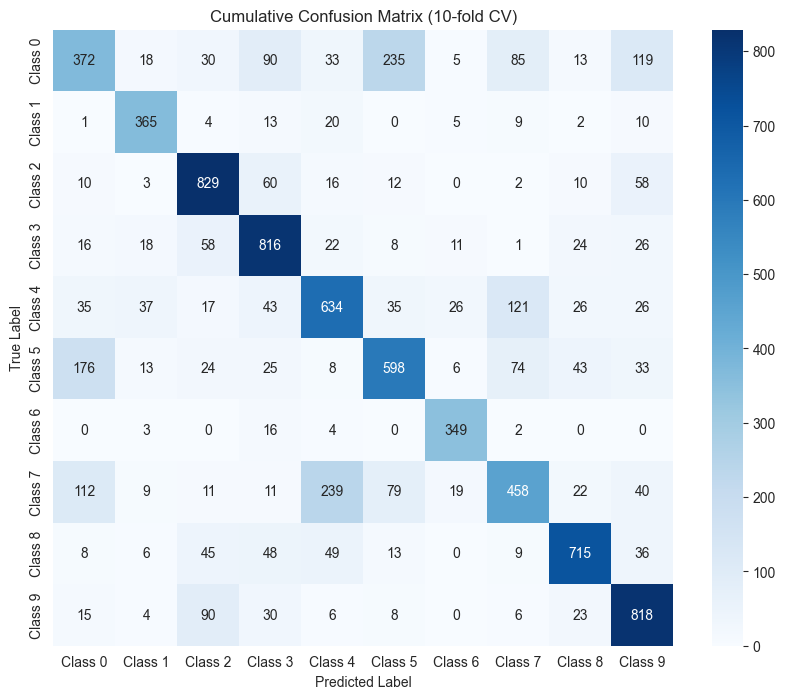

In [34]:
accuracies, f1_scores, conf_mat = cross_validate(
    df=MLP_features,
    features_list=list(selected_columns),
    model_class=AudioMLP,
    num_classes=10
)
class_names = [f"Class {i}" for i in range(10)]
plot_confusion_matrix(conf_mat, class_names)

### Treino do MLP Feature Selection (Percentil 25)


=== FOLD 1/10 ===
Fold 1 Accuracy: 0.5911, F1-score (macro): 0.6089

=== FOLD 2/10 ===
Fold 2 Accuracy: 0.6622, F1-score (macro): 0.6842

=== FOLD 3/10 ===
Fold 3 Accuracy: 0.6097, F1-score (macro): 0.6305

=== FOLD 4/10 ===
Fold 4 Accuracy: 0.7040, F1-score (macro): 0.6907

=== FOLD 5/10 ===
Fold 5 Accuracy: 0.8013, F1-score (macro): 0.8111

=== FOLD 6/10 ===
Fold 6 Accuracy: 0.6768, F1-score (macro): 0.6982

=== FOLD 7/10 ===
Fold 7 Accuracy: 0.7124, F1-score (macro): 0.7047

=== FOLD 8/10 ===
Fold 8 Accuracy: 0.7146, F1-score (macro): 0.7186

=== FOLD 9/10 ===
Fold 9 Accuracy: 0.7096, F1-score (macro): 0.7213

=== FOLD 10/10 ===
Fold 10 Accuracy: 0.8088, F1-score (macro): 0.8220

Cross-validation concluída:
Average Accuracy: 0.6991 ± 0.0668
Average F1-score (macro): 0.7090 ± 0.0638


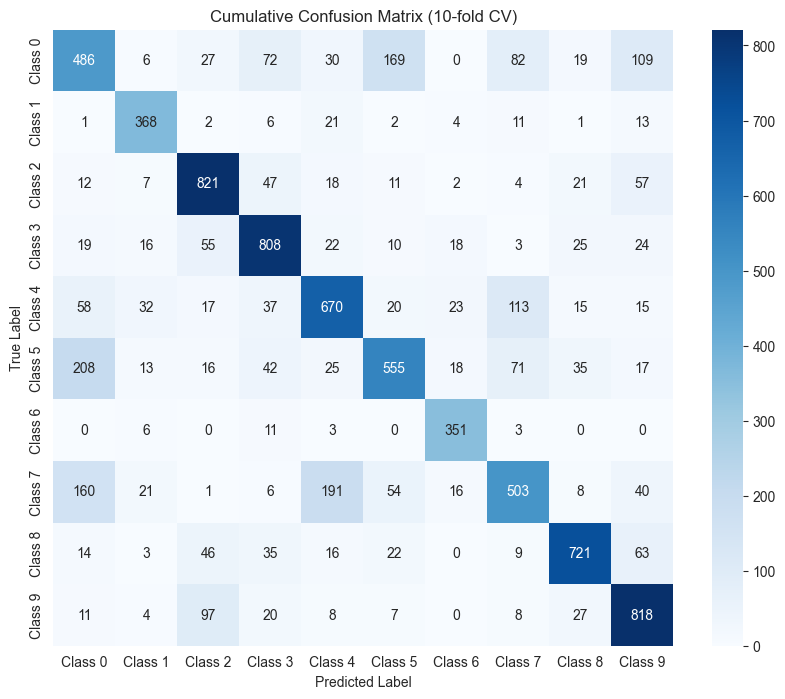

In [35]:
accuracies, f1_scores, conf_mat = cross_validate(
    df=MLP_features,
    features_list=list(X_selected_features_25),
    model_class=AudioMLP,
    num_classes=10
)
class_names = [f"Class {i}" for i in range(10)]
plot_confusion_matrix(conf_mat, class_names)

### Treino do MLP Feature Selection (Percentil 50)


=== FOLD 1/10 ===
Fold 1 Accuracy: 0.6334, F1-score (macro): 0.6488

=== FOLD 2/10 ===
Fold 2 Accuracy: 0.7196, F1-score (macro): 0.7369

=== FOLD 3/10 ===
Fold 3 Accuracy: 0.6714, F1-score (macro): 0.6797

=== FOLD 4/10 ===
Fold 4 Accuracy: 0.7061, F1-score (macro): 0.6974

=== FOLD 5/10 ===
Fold 5 Accuracy: 0.7415, F1-score (macro): 0.7497

=== FOLD 6/10 ===
Fold 6 Accuracy: 0.6476, F1-score (macro): 0.6667

=== FOLD 7/10 ===
Fold 7 Accuracy: 0.6432, F1-score (macro): 0.6563

=== FOLD 8/10 ===
Fold 8 Accuracy: 0.5831, F1-score (macro): 0.5965

=== FOLD 9/10 ===
Fold 9 Accuracy: 0.7194, F1-score (macro): 0.7218

=== FOLD 10/10 ===
Fold 10 Accuracy: 0.7646, F1-score (macro): 0.7764

Cross-validation concluída:
Average Accuracy: 0.6830 ± 0.0535
Average F1-score (macro): 0.6930 ± 0.0514


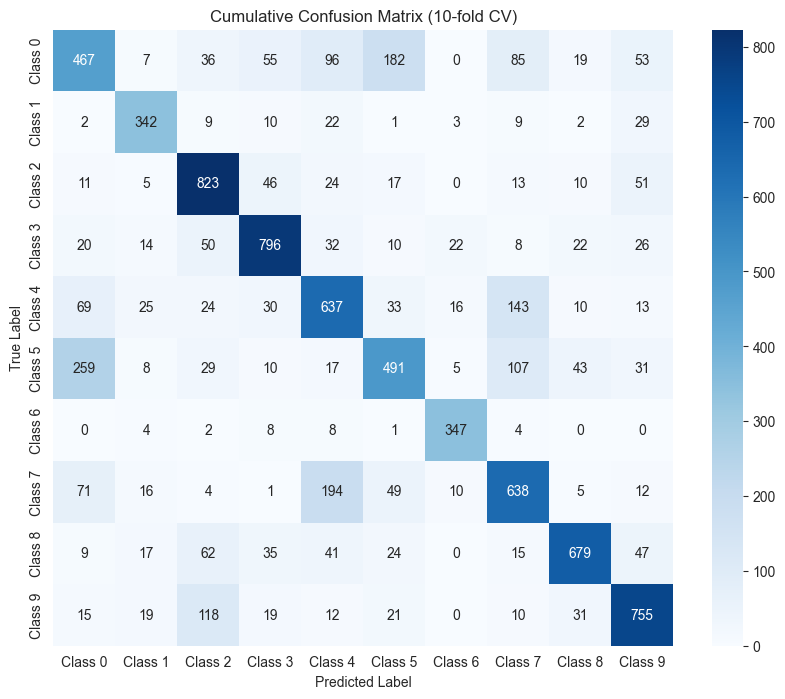

In [36]:
accuracies, f1_scores, conf_mat = cross_validate(
    df=MLP_features,
    features_list=list(X_selected_features_50),
    model_class=AudioMLP,
    num_classes=10
)
class_names = [f"Class {i}" for i in range(10)]
plot_confusion_matrix(conf_mat, class_names)

### Treino do MLP Feature Selection (Percentil 75)


=== FOLD 1/10 ===
Fold 1 Accuracy: 0.5991, F1-score (macro): 0.6111

=== FOLD 2/10 ===
Fold 2 Accuracy: 0.5935, F1-score (macro): 0.5872

=== FOLD 3/10 ===
Fold 3 Accuracy: 0.6162, F1-score (macro): 0.6162

=== FOLD 4/10 ===
Fold 4 Accuracy: 0.6343, F1-score (macro): 0.6262

=== FOLD 5/10 ===
Fold 5 Accuracy: 0.6677, F1-score (macro): 0.6823

=== FOLD 6/10 ===
Fold 6 Accuracy: 0.6173, F1-score (macro): 0.6377

=== FOLD 7/10 ===
Fold 7 Accuracy: 0.6050, F1-score (macro): 0.5998

=== FOLD 8/10 ===
Fold 8 Accuracy: 0.6290, F1-score (macro): 0.6317

=== FOLD 9/10 ===
Fold 9 Accuracy: 0.7206, F1-score (macro): 0.7224

=== FOLD 10/10 ===
Fold 10 Accuracy: 0.6750, F1-score (macro): 0.6872

Cross-validation concluída:
Average Accuracy: 0.6358 ± 0.0382
Average F1-score (macro): 0.6402 ± 0.0411


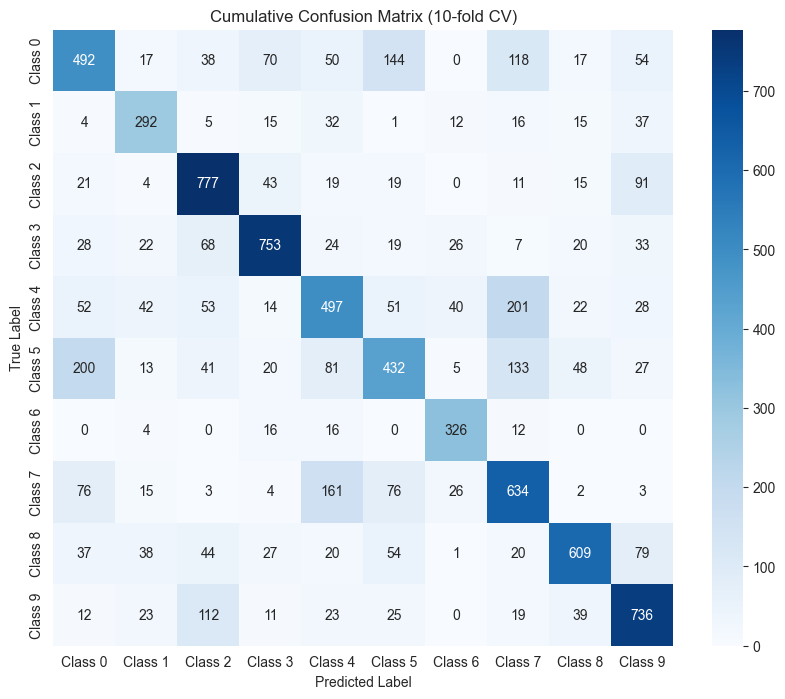

In [37]:
accuracies, f1_scores, conf_mat = cross_validate(
    df=MLP_features,
    features_list=list(X_selected_features_75),
    model_class=AudioMLP,
    num_classes=10
)
class_names = [f"Class {i}" for i in range(10)]
plot_confusion_matrix(conf_mat, class_names)

#### Conclusões: Para o MLP o Feature Selection com recurso ao ANOVA F-Teste onde F1-score está acima do 1º Quartil é o modelo com melhores resultados, mas a maioria das features extraídas a partir dos MFCCs são relevantes, visto que a melhoria observada é de cerca de 2% para um feature selection conservador.

## Hyper-Paramater Optimizer

train_HPO é uma função adaptada do train_one_fold para treinar o Inner CV e o Outer CV

### Inner loop (Hyperparameter Optimization)
- Função run_hpo:
  - Realiza K-Fold (interno) apenas no conjunto de treino do fold externo.
  - Testa todas as combinações de hiperparâmetros do param_grid.
  - Treina o modelo usando train_HPO (com early stopping).
  - Calcula a acurácia média de validação.
  - Retorna os *melhores hiperparâmetros* para o fold externo.

### Outer loop (validação externa)
- Divide os dados em outer_folds folds.
- Para cada fold:
  - Dados de treino e teste são separados.
  - *Inner loop* é usado para otimização de hiperparâmetros (HPO).
  - Após HPO, treina-se o *modelo final* no fold externo usando os melhores parâmetros encontrados.
  - Avalia o modelo no fold de teste externo.
  - Salva os melhores pesos e hiperparâmetros se a acurácia for superior ao modelo anterior.

In [38]:
def train_HPO(model, train_loader, val_loader,
              lr=1e-3, weight_decay=1e-5,
              class_weights=None, max_epochs=50,
              patience=7):

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss(weight=class_weights) if class_weights is not None else nn.CrossEntropyLoss()

    best_state = None
    best_val_acc = 0
    patience_counter = 0

    for epoch in range(max_epochs):
        # Train
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        # Validation
        model.eval()
        y_true, y_pred = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                preds = logits.argmax(1).cpu().numpy()
                y_true.extend(yb.cpu().numpy())
                y_pred.extend(preds)

        val_acc = accuracy_score(y_true, y_pred)

        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model

In [39]:
# -------------------------------
# Hyperparameter optimization (inner CV)
# -------------------------------
def run_hpo(X_train, y_train, param_grid, inner_folds=3, input_dim=None):
    kf = KFold(n_splits=inner_folds, shuffle=True, random_state=42)
    best_params = None
    best_score = -np.inf

    for params in param_grid:
        lr = params["lr"]
        batch_size = params["batch_size"]
        dropout = params["dropout"]

        print(f"\n🔍 Testing hyperparameters: {params}")
        fold_scores = []

        for train_idx, val_idx in kf.split(X_train):
            X_tr, X_val = X_train[train_idx], X_train[val_idx]
            y_tr, y_val = y_train[train_idx], y_train[val_idx]

            # Datasets
            train_loader = DataLoader(TensorDataset(torch.tensor(X_tr, dtype=torch.float32),
                                                    torch.tensor(y_tr, dtype=torch.long)),
                                      batch_size=batch_size, shuffle=True)
            val_loader = DataLoader(TensorDataset(torch.tensor(X_val, dtype=torch.float32),
                                                  torch.tensor(y_val, dtype=torch.long)),
                                    batch_size=batch_size)

            # Model
            model = AudioMLP(input_dim=input_dim).to(device)
            # Ajusta dropout dinamicamente
            model.model[3].p = dropout
            model.model[7].p = dropout * 0.8
            model.model[11].p = dropout * 0.5

            # Class weights
            class_weights_np = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
            class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(device)

            # Train with early stopping
            model = train_HPO(model, train_loader, val_loader,
                              lr=lr, class_weights=class_weights, max_epochs=30, patience=5)

            # Validation accuracy
            model.eval()
            correct, total = 0, 0
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    preds = model(xb).argmax(1)
                    correct += (preds == yb).sum().item()
                    total += len(yb)
            fold_scores.append(correct / total)

        mean_score = np.mean(fold_scores)
        print(f"   -> Mean inner CV accuracy: {mean_score:.4f}")

        if mean_score > best_score:
            best_score = mean_score
            best_params = params

    print(f"\n✨ Best hyperparameters found: {best_params}\n")
    return best_params

In [40]:
def nested_cross_validation(X, y, param_grid, outer_folds=10):
    kf = KFold(n_splits=outer_folds, shuffle=True, random_state=42)
    outer_scores = []
    outer_f1_scores = []
    outer_best_params = []

    best_acc = -1
    best_model_state = None
    best_model_params = None

    for fold, (train_idx, test_idx) in enumerate(kf.split(X), 1):
        print(f"\n==============================")
        print(f"   OUTER FOLD {fold}/{outer_folds}")
        print(f"==============================")

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        input_dim = X_train.shape[1]

        # --- HPO inner-loop ---
        best_params = run_hpo(X_train, y_train, param_grid, inner_folds=3, input_dim=input_dim)
        outer_best_params.append(best_params)

        batch_size = best_params["batch_size"]
        lr = best_params["lr"]
        dropout = best_params["dropout"]

        # Create dataloaders for outer fold
        train_loader = DataLoader(TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                                                torch.tensor(y_train, dtype=torch.long)),
                                  batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(TensorDataset(torch.tensor(X_test, dtype=torch.float32),
                                               torch.tensor(y_test, dtype=torch.long)),
                                 batch_size=batch_size)

        # Model
        model = AudioMLP(input_dim=input_dim).to(device)
        model.model[3].p = dropout
        model.model[7].p = dropout * 0.8
        model.model[11].p = dropout * 0.5

        # Class weights
        class_weights_np = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
        class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(device)

        # Train final model with early stopping
        model = train_HPO(model, train_loader, test_loader, lr=lr, class_weights=class_weights, max_epochs=50, patience=7)

        # Evaluate outer fold
        model.eval()
        y_true, y_pred = [], []
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                preds = logits.argmax(1).cpu().numpy()
                y_true.extend(yb.cpu().numpy())
                y_pred.extend(preds)
        acc = accuracy_score(y_true, y_pred)
        f1_macro = f1_score(y_true, y_pred, average='macro')
        outer_scores.append(acc)
        outer_f1_scores.append(f1_macro)

        # Salva o melhor modelo de todos os folds
        if acc > best_acc:
            best_acc = acc
            best_model_state = model.state_dict()
            best_model_params = best_params

        print(f"⭐ Outer fold {fold} accuracy: {acc:.4f} | F1-macro: {f1_macro:.4f}")
        print(f"Best params for this fold: {best_params}")

    # Após todos os folds, salva o melhor modelo
    if best_model_state is not None:
        torch.save(best_model_state, "best_nestedcv_model.pt")
        print(f"\nModelo com melhor accuracy ({best_acc:.4f}) salvo em 'best_nestedcv_model.pt'")
        print(f"Melhores hiperparâmetros: {best_model_params}")

    print("\n==============================")
    print(" Final Nested CV Results")
    print("==============================")
    print(f"Mean Accuracy: {np.mean(outer_scores):.4f}")
    print(f"Std Accuracy : {np.std(outer_scores):.4f}")
    print(f"Mean F1-macro: {np.mean(outer_f1_scores):.4f} ± {np.std(outer_f1_scores):.4f}")

    return outer_scores, outer_f1_scores, outer_best_params

In [46]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # y_int será array de inteiros 0..9


print(f"Classes: {le.classes_}")


Classes: ['air_conditioner' 'car_horn' 'children_playing' 'dog_bark' 'drilling'
 'engine_idling' 'gun_shot' 'jackhammer' 'siren' 'street_music']


### Treino final do fold externo
- Criação de DataLoaders (train_loader, test_loader) com o batch size otimizado.
- Inicialização do modelo (AudioMLP) com dropout ajustado.
- Cálculo de *class weights* para classes desbalanceadas.
- Treino com train_HPO:
  - Utiliza early stopping baseado na acurácia de validação.
- Avaliação final:
  - Acumula-se accuracy, F1-macro e confusion matrix
- Após todos os folds:
  - Calcula-se a média e desvio padrão das métricas.
  - Salva-se o *melhor modelo* (best_nestedcv_model.pt) com seus hiperparâmetros.

In [42]:
param_grid = [
    # batch_size 64
    {"lr": 1e-3, "batch_size": 64,  "dropout": 0.1},
    {"lr": 1e-3, "batch_size": 64,  "dropout": 0.2},
    {"lr": 1e-3, "batch_size": 64,  "dropout": 0.3},
    {"lr": 5e-4, "batch_size": 64,  "dropout": 0.1},
    {"lr": 5e-4, "batch_size": 64,  "dropout": 0.2},
    {"lr": 5e-4, "batch_size": 64,  "dropout": 0.3},
    {"lr": 1e-4, "batch_size": 64,  "dropout": 0.1},
    {"lr": 1e-4, "batch_size": 64,  "dropout": 0.2},
    {"lr": 1e-4, "batch_size": 64,  "dropout": 0.3},
    # batch_size 128
    {"lr": 1e-3, "batch_size": 128, "dropout": 0.1},
    {"lr": 1e-3, "batch_size": 128, "dropout": 0.2},
    {"lr": 1e-3, "batch_size": 128, "dropout": 0.3},
    {"lr": 5e-4, "batch_size": 128, "dropout": 0.1},
    {"lr": 5e-4, "batch_size": 128, "dropout": 0.2},
    {"lr": 5e-4, "batch_size": 128, "dropout": 0.3},
    {"lr": 1e-4, "batch_size": 128, "dropout": 0.1},
    {"lr": 1e-4, "batch_size": 128, "dropout": 0.2},
    {"lr": 1e-4, "batch_size": 128, "dropout": 0.3},
    # batch_size 256
    {"lr": 1e-3, "batch_size": 256, "dropout": 0.1},
    {"lr": 1e-3, "batch_size": 256, "dropout": 0.2},
    {"lr": 1e-3, "batch_size": 256, "dropout": 0.3},
    {"lr": 5e-4, "batch_size": 256, "dropout": 0.1},
    {"lr": 5e-4, "batch_size": 256, "dropout": 0.2},
    {"lr": 5e-4, "batch_size": 256, "dropout": 0.3},
    {"lr": 1e-4, "batch_size": 256, "dropout": 0.1},
    {"lr": 1e-4, "batch_size": 256, "dropout": 0.2},
    {"lr": 1e-4, "batch_size": 256, "dropout": 0.3},
]

outer_scores, outer_f1_scores, outer_best_params = nested_cross_validation(
    X=X[X_selected_features_25].values,  # usa apenas as features selecionadas
    y=y_encoded,                          # labels codificadas como inteiros
    param_grid=param_grid,
    outer_folds=10
)


   OUTER FOLD 1/10

🔍 Testing hyperparameters: {'lr': 0.001, 'batch_size': 64, 'dropout': 0.1}


   -> Mean inner CV accuracy: 0.8053

🔍 Testing hyperparameters: {'lr': 0.001, 'batch_size': 64, 'dropout': 0.2}
   -> Mean inner CV accuracy: 0.7544

🔍 Testing hyperparameters: {'lr': 0.001, 'batch_size': 64, 'dropout': 0.3}
   -> Mean inner CV accuracy: 0.7630

🔍 Testing hyperparameters: {'lr': 0.0005, 'batch_size': 64, 'dropout': 0.1}
   -> Mean inner CV accuracy: 0.7586

🔍 Testing hyperparameters: {'lr': 0.0005, 'batch_size': 64, 'dropout': 0.2}
   -> Mean inner CV accuracy: 0.7938

🔍 Testing hyperparameters: {'lr': 0.0005, 'batch_size': 64, 'dropout': 0.3}
   -> Mean inner CV accuracy: 0.7597

🔍 Testing hyperparameters: {'lr': 0.0001, 'batch_size': 64, 'dropout': 0.1}
   -> Mean inner CV accuracy: 0.7181

🔍 Testing hyperparameters: {'lr': 0.0001, 'batch_size': 64, 'dropout': 0.2}
   -> Mean inner CV accuracy: 0.6550

🔍 Testing hyperparameters: {'lr': 0.0001, 'batch_size': 64, 'dropout': 0.3}
   -> Mean inner CV accuracy: 0.6008

🔍 Testing hyperparameters: {'lr': 0.001, 'batch_size

In [44]:
print("\n🔹 Resultados finais do Nested CV")
for i, (acc, f1, params) in enumerate(zip(outer_scores, outer_f1_scores, outer_best_params), 1):
    print(f"Fold {i}: Accuracy = {acc:.4f}, F1-macro = {f1:.4f}, Best params = {params}")

print(f"\nMédia Accuracy: {np.mean(outer_scores):.4f} ± {np.std(outer_scores):.4f}")
print(f"Média F1-macro: {np.mean(outer_f1_scores):.4f} ± {np.std(outer_f1_scores):.4f}")



🔹 Resultados finais do Nested CV
Fold 1: Accuracy = 0.8787, F1-macro = 0.8837, Best params = {'lr': 0.001, 'batch_size': 256, 'dropout': 0.1}
Fold 2: Accuracy = 0.8604, F1-macro = 0.8661, Best params = {'lr': 0.0005, 'batch_size': 64, 'dropout': 0.1}
Fold 3: Accuracy = 0.8729, F1-macro = 0.8791, Best params = {'lr': 0.0005, 'batch_size': 128, 'dropout': 0.1}
Fold 4: Accuracy = 0.8499, F1-macro = 0.8573, Best params = {'lr': 0.001, 'batch_size': 64, 'dropout': 0.1}
Fold 5: Accuracy = 0.8499, F1-macro = 0.8500, Best params = {'lr': 0.0005, 'batch_size': 128, 'dropout': 0.1}
Fold 6: Accuracy = 0.8923, F1-macro = 0.8947, Best params = {'lr': 0.0005, 'batch_size': 128, 'dropout': 0.1}
Fold 7: Accuracy = 0.8786, F1-macro = 0.8859, Best params = {'lr': 0.001, 'batch_size': 256, 'dropout': 0.1}
Fold 8: Accuracy = 0.8316, F1-macro = 0.8357, Best params = {'lr': 0.0005, 'batch_size': 64, 'dropout': 0.1}
Fold 9: Accuracy = 0.8545, F1-macro = 0.8576, Best params = {'lr': 0.0005, 'batch_size': 64,

In [50]:
# Carrega o melhor modelo salvo
model = AudioMLP(input_dim=141, num_classes=10).to(device)
model.load_state_dict(torch.load("best_nestedcv_model.pt"))
model.eval()

scaler_selected = StandardScaler()
scaler_selected.fit(MLP_features[X_selected_features_25])
print(X_selected_features_25)
X_selected_features_25 = list(X_selected_features_25)
X_adv = torch.tensor(
    scaler_selected.transform(MLP_features[X_selected_features_25])[:100],
    dtype=torch.float32
).to(device)
y_adv = torch.tensor(y_encoded[:100], dtype=torch.int64).to(device)

fmodel = fb.PyTorchModel(model, bounds=(float(X_adv.min()), float(X_adv.max())))
attack = fb.attacks.FGSM()
raw, clipped, is_adv = attack(fmodel, X_adv, y_adv, epsilons=0.05)

robust_accuracy = 1 - is_adv.float().mean().item()
print(f"Robust accuracy under DeepFool attack: {robust_accuracy:.4f}")

perturbation = (clipped - X_adv).abs().mean().item()
print(f"Perturbação média (L2): {perturbation:.6f}")

['mfcc_mean_0', 'mfcc_mean_1', 'mfcc_mean_2', 'mfcc_mean_3', 'mfcc_mean_4', 'mfcc_mean_5', 'mfcc_mean_6', 'mfcc_mean_7', 'mfcc_mean_8', 'mfcc_mean_9', 'mfcc_mean_10', 'mfcc_mean_11', 'mfcc_mean_12', 'mfcc_mean_13', 'mfcc_mean_14', 'mfcc_mean_15', 'mfcc_mean_16', 'mfcc_mean_18', 'mfcc_mean_25', 'mfcc_mean_27', 'mfcc_mean_28', 'mfcc_mean_30', 'mfcc_mean_31', 'mfcc_mean_32', 'mfcc_mean_33', 'mfcc_mean_34', 'mfcc_mean_36', 'mfcc_mean_37', 'mfcc_mean_38', 'mfcc_mean_39', 'mfcc_std_0', 'mfcc_std_1', 'mfcc_std_2', 'mfcc_std_3', 'mfcc_std_4', 'mfcc_std_5', 'mfcc_std_6', 'mfcc_std_7', 'mfcc_std_8', 'mfcc_std_9', 'mfcc_std_10', 'mfcc_std_11', 'mfcc_std_12', 'mfcc_std_13', 'mfcc_std_14', 'mfcc_std_15', 'mfcc_std_16', 'mfcc_std_17', 'mfcc_std_18', 'mfcc_std_19', 'mfcc_std_20', 'mfcc_std_21', 'mfcc_std_22', 'mfcc_std_23', 'mfcc_std_24', 'mfcc_std_25', 'mfcc_std_26', 'mfcc_std_27', 'mfcc_std_28', 'mfcc_std_29', 'mfcc_std_30', 'mfcc_std_31', 'mfcc_std_32', 'mfcc_std_33', 'mfcc_std_34', 'mfcc_std_35',

## Conclusão: MLPs são extremamente suscetíveis a DeepFools

Cada neurônio na camada seguinte recebe todos os inputs da camada anterior.

Isso cria muitas direções lineares e quase-lineares no espaço de features.

O DeepFool explora exatamente isso: encontra a menor perturbação em qualquer direção para mudar a classificação.

MLPs não têm restrições estruturais como convoluções ou pooling, então pequenas mudanças em muitas features podem facilmente enganar a rede.